# CNET 5442 — Sports Analytics Through Data and Networks (Spring 2026)

## Class 17: Event-Transition Networks --> Predictive Models

In class 16, we turned one match event log into a directed, weighted network of event-to-event transitions. That was already a big modeling step. We decided what counted as a state, which events belonged in the sequence, and when one state should be connected to the next.

Now we keep going!

A row-normalized transition matrix does not just summarize the past. It gives a probability distribution over what happens next. In other words, the event-transition network from class 16 is already a predictive model. So the natural questions are straightforward:

- given the current event, what does the model think comes next?
- how should we score that prediction?
- compared to what baselines?
- how brittle is that learned transition structure if we deliberately rewire some of it?
- what happens if we redesign the observed state itself rather than keeping the coarse labels fixed?
- how well does the learned grammar transfer to a completely new match?
- and what happens if the important state of the game is *hidden* rather than directly observed?

That arc takes us from a first-order Markov model to second-order models, then to robustness checks, richer observed alphabets, whole-match transfer, and Hidden Markov Models.


### Notation and conventions

We will use the same match as classes 14–16: **Argentina vs. France, 2022 World Cup Final**, from StatsBomb Open Data.

A few conventions matter all the way through:

- We will start with **Argentina-only possession sequences**, just as we did in class 16.
- We will begin with the same **coarse event label** from class 16: `Pass`, `Carry`, `Ball Receipt*`, `Shot`, and so on.
- Later, we will deliberately decorate those labels with **pressure flags** and a coarse **3x3 pitch bin** to see what that changes.
- A sequence will usually be written as $x_1, x_2, \ldots, x_T$, where $x_t$ is the observed event at step $t$.
- When we add `START` and `END`, those are bookkeeping states for possession boundaries, not real on-ball actions.
- Unless we say otherwise, all prediction scores are computed on **held-out data** that the model did not see during fitting.
- We will use natural logarithms for log-loss. That means perplexity is $\exp(L)$ when $L$ is the mean log-loss in nats.


### Prediction, scoring, and football action value

There are really two literatures meeting here:

One is the football analytics literature that asks how possessions, actions, and context translate into future value. Rudd's Markov-chain work is an early landmark. Decroos and collaborators pushed this toward event-valuing with VAEP. Fernández, Bornn, and Cervone pushed further with a fine-grained expected possession value framework that uses richer spatial and temporal information. Robberechts and collaborators extend the same spirit to pressing and passing creativity.

The other is the statistical forecasting literature. If a model outputs a *probability distribution*, then we need a scoring rule that respects probabilities, not just top-1 guesses. That is where log-loss, cross-entropy, Shannon information, and proper scoring rules come in.


### Memory, higher-order dependence, and hidden state

The warning behind today's notebook is simple: a first-order network can hide real sequential structure.

Rosvall et al. (2014), Scholtes (2017), and Lambiotte, Rosvall, and Scholtes (2019) make that point in network science very clearly. If where you go next depends on where you came from, a first-order graph is compressing away information. That is exactly why second-order event models are worth trying.

Then there is a second warning: maybe the most important state is not directly observed at all. Hidden Markov Models are the classical answer to that idea. Rabiner (1989) remains the standard tutorial, and Baum, Petrie, Bilmes, and Viterbi are the core names behind the algorithms.


### Data and software anchors

For data semantics, the two most important sources are the **StatsBomb Open Data repository** and the **StatsBomb Open Data Specification**. One small schema detail from those sources matters immediately: completed open-play passes often have no explicit `pass.outcome`, so missing `pass.outcome` is not an error. It usually means the pass was completed.

For HMMs, the standard Python package would normally be `hmmlearn`. In this environment, it is not installed, so we will build a minimal categorical HMM ourselves. That turns out to be pedagogically useful anyway, because we get to see the actual moving parts.


## 0. Setup

We will reuse the class 16 choices wherever possible. Same match. Same coarse state space. Same possession slicing logic. The new work starts when we turn those transitions into scored predictions.


In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import importlib.util
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SEED = 5442
rng = np.random.default_rng(SEED)

plt.rcParams["figure.dpi"] = 200
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 100)
pd.set_option("display.precision", 4)

COLOR_MAIN = "#1f77b4"
COLOR_SECOND = "#2ca02c"
COLOR_ACCENT = "#ff7f0e"
COLOR_BASELINE = "#d62728"
COLOR_REFERENCE = "#7f7f7f"
COLOR_LATENT = "#9467bd"
COLOR_SIM = "#8c564b"

DATA_ROOT = Path("data/statsbomb_open_data")
MATCH_ID = 3869685
TEAM_NAME = "Argentina"

print(f"Seed: {SEED}")
print(f"hmmlearn available? {importlib.util.find_spec('hmmlearn') is not None}")


Seed: 5442
hmmlearn available? False


In [2]:
STRUCTURAL_EVENTS = {
    "Starting XI", "Half Start", "Half End", "Substitution", "Tactical Shift",
    "Injury Stoppage", "Player Off", "Player On", "Bad Behaviour"
}

TEAM_ACTION_TYPES = {
    "50/50", "Ball Recovery", "Ball Receipt*", "Block", "Carry", "Clearance",
    "Dispossessed", "Dribble", "Duel", "Foul Committed", "Foul Won",
    "Goal Keeper", "Interception", "Miscontrol", "Offside", "Pass", "Shot"
}

RENAME_MAP = {
    "type.name": "event_type",
    "team.name": "team_name",
    "player.name": "player_name",
    "possession_team.name": "possession_team_name",
    "play_pattern.name": "play_pattern_name",
    "pass.recipient.name": "pass_recipient_name",
    "pass.end_location": "pass_end_location",
    "pass.height.name": "pass_height_name",
    "pass.type.name": "pass_type_name",
    "pass.outcome.name": "pass_outcome_name",
    "shot.outcome.name": "shot_outcome_name",
    "shot.type.name": "shot_type_name",
    "dribble.outcome.name": "dribble_outcome_name",
    "duel.type.name": "duel_type_name",
    "duel.outcome.name": "duel_outcome_name",
    "ball_receipt.outcome.name": "ball_receipt_outcome_name",
    "foul_committed.card.name": "foul_committed_card_name",
    "goalkeeper.type.name": "goalkeeper_type_name",
}

def extract_xy(location):
    if isinstance(location, (list, tuple)) and len(location) >= 2:
        return float(location[0]), float(location[1])
    return np.nan, np.nan

def state_coarse(row):
    return row["event_type"]

def build_team_possession_slice(events_df, team_name, periods=(1, 2, 3, 4), state_func=state_coarse):
    mask = (
        events_df["is_gameplay"]
        & events_df["period"].isin(periods)
        & (events_df["team_name"] == team_name)
        & (events_df["possession_team_name"] == team_name)
        & events_df["event_type"].isin(TEAM_ACTION_TYPES)
    )
    out = events_df.loc[mask].copy()
    out = out.sort_values(["period", "minute", "second", "index"]).reset_index(drop=True)
    out["state"] = out.apply(state_func, axis=1)
    return out

def extract_sequences_from_df(df, state_col="state", group_col="possession", sort_cols=("index",)):
    sequences = []
    meta_rows = []
    for possession, group in df.sort_values(list(sort_cols)).groupby(group_col, sort=False):
        seq = group[state_col].tolist()
        if len(seq) >= 2:
            sequences.append(seq)
            first = group.iloc[0]
            meta_rows.append({
                "possession": possession,
                "period": int(first["period"]),
                "minute": int(first["minute"]),
                "second": int(first["second"]),
                "n_events": len(seq),
                "start_index": int(first["index"]),
                "end_index": int(group["index"].iloc[-1]),
            })
    return sequences, pd.DataFrame(meta_rows)

def vocabulary_from_sequences(sequences):
    states = sorted({state for seq in sequences for state in seq})
    state_to_idx = {state: i for i, state in enumerate(states)}
    return states, state_to_idx

def transition_counts(sequences, states):
    state_to_idx = {state: i for i, state in enumerate(states)}
    counts = np.zeros((len(states), len(states)), dtype=float)
    for seq in sequences:
        for a, b in zip(seq[:-1], seq[1:]):
            counts[state_to_idx[a], state_to_idx[b]] += 1
    return counts

def row_normalize(counts, alpha=0.0):
    counts = counts.astype(float) + alpha
    row_sums = counts.sum(axis=1, keepdims=True)
    uniform = np.full_like(counts, 1 / counts.shape[1], dtype=float)
    return np.divide(counts, row_sums, out=uniform, where=row_sums > 0)

def marginal_distribution(sequences, states):
    counts = Counter()
    for seq in sequences:
        counts.update(seq[1:])
    total = sum(counts.values())
    return np.array([counts[state] / total for state in states], dtype=float)

def score_next_event_model(sequences, predict_func, states, state_to_idx, clip=1e-15, min_context_len=1):
    losses = []
    rows = []
    for seq_id, seq in enumerate(sequences):
        for t in range(min_context_len, len(seq)):
            context = seq[:t]
            truth = seq[t]
            probs = np.array(predict_func(context), dtype=float)
            if probs.sum() <= 0:
                probs = np.zeros(len(states), dtype=float)
            p_raw = probs[state_to_idx[truth]] if probs.sum() > 0 else 0.0
            p = max(p_raw, clip)
            loss = -np.log(p)
            losses.append(loss)
            rows.append({
                "sequence_id": seq_id,
                "step": t,
                "context_len": len(context),
                "prev_state": context[-1],
                "true_next_state": truth,
                "prob_true_raw": p_raw,
                "prob_true": p,
                "loss_nats": loss,
            })
    mean_loss = float(np.mean(losses))
    return {
        "n_transitions": len(losses),
        "mean_log_loss_nats": mean_loss,
        "mean_log_loss_bits": mean_loss / np.log(2),
        "perplexity": float(np.exp(mean_loss)),
        "details": pd.DataFrame(rows),
    }

def collect_predictions(sequences, predict_func, states, state_to_idx, min_context_len=1):
    rows = []
    for seq_id, seq in enumerate(sequences):
        for t in range(min_context_len, len(seq)):
            context = seq[:t]
            truth = seq[t]
            probs = np.array(predict_func(context), dtype=float)
            probs = probs / probs.sum()
            pred_idx = int(np.argmax(probs))
            rows.append({
                "sequence_id": seq_id,
                "step": t,
                "prev_state": context[-1],
                "true_next_state": truth,
                "predicted_next_state": states[pred_idx],
                "prob_true": float(probs[state_to_idx[truth]]),
                "prob_pred": float(probs[pred_idx]),
            })
    return pd.DataFrame(rows)

def top_k_from_probs(probs, states, k=3):
    order = np.argsort(probs)[::-1][:k]
    return [(states[i], float(probs[i])) for i in order]

def add_start_end(sequences, start="START", end="END"):
    return [[start] + seq + [end] for seq in sequences]

def simulate_sequence(P, states, start="START", end="END", rng=None, max_steps=300):
    if rng is None:
        rng = np.random.default_rng()
    state_to_idx = {state: i for i, state in enumerate(states)}
    current = start
    seq = [current]
    for _ in range(max_steps):
        probs = P[state_to_idx[current]]
        nxt = rng.choice(states, p=probs)
        seq.append(nxt)
        current = nxt
        if current == end:
            break
    return seq

def plot_heatmap(df, title, xlabel, ylabel, cmap="viridis", annotate=False, fmt="{:.2f}", figsize=(8, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(df.to_numpy(), aspect="auto", cmap=cmap)
    ax.set_xticks(np.arange(df.shape[1]))
    ax.set_xticklabels(df.columns, rotation=90)
    ax.set_yticks(np.arange(df.shape[0]))
    ax.set_yticklabels(df.index)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    cbar = fig.colorbar(im, ax=ax)
    if annotate:
        for i in range(df.shape[0]):
            for j in range(df.shape[1]):
                ax.text(j, i, fmt.format(df.iat[i, j]), ha="center", va="center", fontsize=7)
    fig.tight_layout()
    plt.show()

def hidden_state_label(top_observed_state):
    if top_observed_state == "Pass":
        return "Pass / release"
    if top_observed_state == "Ball Receipt*":
        return "Receipt"
    if top_observed_state == "Carry":
        return "Carry"
    if top_observed_state in {"Ball Recovery", "Dribble", "Duel", "Dispossessed", "Interception", "Block"}:
        return "Contest / recovery"
    if top_observed_state == "Shot":
        return "Shot / finish"
    return f"Mostly {top_observed_state}"

def reorder_hidden_states(emission_df):
    priority = {
        "Pass": 0,
        "Ball Receipt*": 1,
        "Carry": 2,
        "Ball Recovery": 3,
        "Dribble": 4,
        "Shot": 5,
    }
    top_states = emission_df.idxmax(axis=1)
    order = sorted(
        range(len(emission_df)),
        key=lambda i: (priority.get(top_states.iloc[i], 99), emission_df.index[i])
    )
    return emission_df.iloc[order], order


In [3]:
with open(DATA_ROOT / "events" / f"{MATCH_ID}.json") as f:
    events = json.load(f)

with open(DATA_ROOT / "matches" / "43" / "106.json") as f:
    matches = json.load(f)

match_row = next(match for match in matches if match["match_id"] == MATCH_ID)

events_df = pd.json_normalize(events, sep=".")
events_df = events_df.rename(columns=RENAME_MAP).copy()
events_df["under_pressure"] = (
    events_df["under_pressure"]
    .where(events_df["under_pressure"].notna(), False)
    .astype(bool)
)
events_df["is_gameplay"] = ~events_df["event_type"].isin(STRUCTURAL_EVENTS)
events_df[["x", "y"]] = events_df["location"].apply(lambda loc: pd.Series(extract_xy(loc)))

match_summary = pd.DataFrame(
    {
        "match_id": [MATCH_ID],
        "competition": [match_row["competition"]["competition_name"]],
        "season": [match_row["season"]["season_name"]],
        "stage": [match_row["competition_stage"]["name"]],
        "home_team": [match_row["home_team"]["home_team_name"]],
        "away_team": [match_row["away_team"]["away_team_name"]],
        "score": [f"{match_row['home_score']}-{match_row['away_score']}"],
        "stadium": [match_row["stadium"]["name"]],
        "match_date": [match_row["match_date"]],
    }
)

display(match_summary)
print(f"Raw event rows: {len(events_df):,}")


,match_id,competition,season,stage,home_team,away_team,score,stadium,match_date
0,3869685,FIFA World Cup,2022,Final,Argentina,France,3-3,Lusail Stadium,2022-12-18


Raw event rows: 4,407


## 1. Rebuilding the class 16 event-state data slice

We do **not** want to reinvent the earlier notebook. We want to stand on it.

So we keep the same basic modeling decision from class 16: isolate one team's on-ball actions within its own possessions, then map each event to a coarse state label. We will use Argentina and keep periods 1–4 so that extra time is included but the penalty shootout is not.


In [4]:
argentina_df = build_team_possession_slice(events_df, TEAM_NAME, periods=(1, 2, 3, 4), state_func=state_coarse)
sequences, sequence_meta = extract_sequences_from_df(argentina_df)
states, state_to_idx = vocabulary_from_sequences(sequences)

slice_summary = pd.DataFrame(
    {
        "team": [TEAM_NAME],
        "event_rows_kept": [len(argentina_df)],
        "usable_possessions": [len(sequences)],
        "distinct_coarse_states": [len(states)],
        "first_period": [sequence_meta["period"].min()],
        "last_period": [sequence_meta["period"].max()],
    }
)

display(slice_summary)
display(pd.DataFrame({"state": states}))


,team,event_rows_kept,usable_possessions,distinct_coarse_states,first_period,last_period
0,Argentina,1934,109,17,1,4


,state
0,50/50
1,Ball Receipt*
2,Ball Recovery
3,Block
4,Carry
5,Clearance
6,Dispossessed
7,Dribble
8,Duel
9,Foul Committed


In [5]:
period_summary = (
    sequence_meta.groupby("period")
    .agg(
        possessions=("possession", "count"),
        mean_events=("n_events", "mean"),
        median_events=("n_events", "median"),
    )
    .round(2)
)
display(period_summary)


,possessions,mean_events,median_events
period,,,
1,40,22.05,14.0
2,42,14.05,9.5
3,13,19.85,18.0
4,14,14.29,12.5


A quick reality check: the state space is small enough to estimate transitions, but rich enough that `Pass`, `Ball Receipt*`, `Carry`, `Shot`, and recovery events stay distinct. That is exactly what we want for a first pass at predictive sequence modeling.


## 2. Train/test split

A random split would be fine for many machine-learning tasks, but here a chronological split is more honest. We fit on earlier possessions and score on later possessions. That way the test data really is "the future" relative to the training data.

We will use the first 75% of Argentina possessions for training and the final 25% for testing.


In [6]:
split_idx = int(np.floor(0.75 * len(sequences)))

train_sequences = sequences[:split_idx]
test_sequences = sequences[split_idx:]

train_meta = sequence_meta.iloc[:split_idx].copy()
test_meta = sequence_meta.iloc[split_idx:].copy()

split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "possessions": [len(train_sequences), len(test_sequences)],
        "mean_events_per_possession": [
            np.mean([len(seq) for seq in train_sequences]),
            np.mean([len(seq) for seq in test_sequences]),
        ],
        "first_minute": [train_meta["minute"].min(), test_meta["minute"].min()],
        "last_minute": [train_meta["minute"].max(), test_meta["minute"].max()],
    }
).round(2)

display(split_summary)

period_split = (
    pd.concat(
        [
            train_meta.assign(split="train"),
            test_meta.assign(split="test"),
        ],
        ignore_index=True,
    )
    .pivot_table(index="period", columns="split", values="possession", aggfunc="count", fill_value=0)
)
display(period_split)


,split,possessions,mean_events_per_possession,first_minute,last_minute
0,train,81,17.96,0,96
1,test,28,16.96,90,122


split,test,train
period,,
1,0,40
2,1,41
3,13,0
4,14,0


Notice what this split does. The training sample is basically the first two periods. The test sample is the last part of regulation plus extra time. That is a hard generalization problem, and that is a good thing. Easy evaluation usually tells us less.


# Part I — The transition matrix as a predictive model

## 3. A row of $P$ is a prediction

In class 16, we already built a transition matrix. Once we row-normalize the counts, the row for the current state is a full probability distribution over the next state.

So if the current state is `Carry`, the `Carry` row of $P$ tells us how the model spreads its belief across `Pass`, `Shot`, `Dribble`, `Dispossessed`, and everything else.

That means prediction is already sitting there in plain sight.


In [7]:
first_order_counts = transition_counts(train_sequences, states)
P1 = row_normalize(first_order_counts)

transition_df = pd.DataFrame(P1, index=states, columns=states)
display(transition_df.loc[["Ball Recovery", "Pass", "Ball Receipt*", "Carry", "Shot"]].round(3))


,50/50,Ball Receipt*,Ball Recovery,Block,Carry,Clearance,Dispossessed,Dribble,Duel,Foul Committed,Foul Won,Goal Keeper,Interception,Miscontrol,Offside,Pass,Shot
Ball Recovery,0.000,0.000,0.062,0.000,0.906,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.0,0.000,0.031
Pass,0.002,0.958,0.008,0.002,0.000,0.000,0.000,0.000,0.013,0.006,0.000,0.0,0.004,0.000,0.0,0.006,0.000
Ball Receipt*,0.002,0.000,0.012,0.002,0.755,0.002,0.000,0.000,0.005,0.002,0.005,0.0,0.002,0.012,0.0,0.194,0.007
Carry,0.000,0.000,0.000,0.000,0.000,0.000,0.029,0.043,0.000,0.000,0.024,0.0,0.000,0.011,0.0,0.874,0.019
Shot,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.0,1.000,0.000



- After `Pass`, the next state is overwhelmingly `Ball Receipt*`.
- After `Ball Receipt*`, the model mostly expects `Carry`, but an immediate `Pass` is also common.
- After `Carry`, the most likely next state is `Pass`, but `Dribble`, `Dispossessed`, and `Shot` remain live possibilities.
- After `Shot`, the training data is tiny, and the row is brittle. We will come back to that.


## 4. A real possession, step by step

Abstract definitions help. Real sequences help more.

Let's take one late Argentina possession from extra time and walk through it event by event. At each step, we will ask the first-order model, "Given the current state, what do you think happens next?"


In [8]:
target_possession = 228
target_events = argentina_df.loc[argentina_df["possession"] == target_possession].copy()
target_sequence = target_events["state"].tolist()

display(
    target_events[["period", "minute", "second", "index", "event_type", "player_name"]]
    .reset_index(drop=True)
)
print("Observed state sequence:")
print(" -> ".join(target_sequence))


,period,minute,second,index,event_type,player_name
0,4,107,45,4051,Ball Recovery,Leandro Daniel Paredes
1,4,107,45,4052,Carry,Leandro Daniel Paredes
2,4,107,46,4053,Pass,Leandro Daniel Paredes
3,4,107,49,4054,Ball Receipt*,Gonzalo Ariel Montiel
4,4,107,49,4055,Carry,Gonzalo Ariel Montiel
5,4,107,50,4056,Pass,Gonzalo Ariel Montiel
6,4,107,53,4057,Ball Receipt*,Lautaro Javier Martínez
7,4,107,53,4058,Pass,Lautaro Javier Martínez
8,4,107,53,4059,Ball Receipt*,Lionel Andrés Messi Cuccittini
9,4,107,53,4060,Carry,Lionel Andrés Messi Cuccittini


Observed state sequence:
Ball Recovery -> Carry -> Pass -> Ball Receipt* -> Carry -> Pass -> Ball Receipt* -> Pass -> Ball Receipt* -> Carry -> Pass -> Ball Receipt* -> Carry -> Pass -> Ball Receipt* -> Carry -> Shot -> Ball Recovery -> Shot


In [9]:
def predict_first_order(context):
    prev_state = context[-1]
    return P1[state_to_idx[prev_state]]

walk_rows = []
for t in range(1, len(target_sequence)):
    context = target_sequence[:t]
    truth = target_sequence[t]
    probs = np.array(predict_first_order(context), dtype=float)
    top3 = top_k_from_probs(probs, states, k=3)
    walk_rows.append(
        {
            "step": t,
            "current_state": context[-1],
            "actual_next_state": truth,
            "p(actual_next)": probs[state_to_idx[truth]],
            "top_1": top3[0][0],
            "p(top_1)": top3[0][1],
            "top_2": top3[1][0],
            "p(top_2)": top3[1][1],
            "top_3": top3[2][0],
            "p(top_3)": top3[2][1],
        }
    )

walk_df = pd.DataFrame(walk_rows)
display(walk_df.round(4))


,step,current_state,actual_next_state,p(actual_next),top_1,p(top_1),top_2,p(top_2),top_3,p(top_3)
0,1,Ball Recovery,Carry,0.9062,Carry,0.9062,Ball Recovery,0.0625,Shot,0.0312
1,2,Carry,Pass,0.8740,Pass,0.8740,Dribble,0.0429,Dispossessed,0.0295
2,3,Pass,Ball Receipt*,0.9582,Ball Receipt*,0.9582,Duel,0.0126,Ball Recovery,0.0084
3,4,Ball Receipt*,Carry,0.7552,Carry,0.7552,Pass,0.1940,Ball Recovery,0.0115
4,5,Carry,Pass,0.8740,Pass,0.8740,Dribble,0.0429,Dispossessed,0.0295
5,6,Pass,Ball Receipt*,0.9582,Ball Receipt*,0.9582,Duel,0.0126,Ball Recovery,0.0084
6,7,Ball Receipt*,Pass,0.1940,Carry,0.7552,Pass,0.1940,Ball Recovery,0.0115
7,8,Pass,Ball Receipt*,0.9582,Ball Receipt*,0.9582,Duel,0.0126,Ball Recovery,0.0084
8,9,Ball Receipt*,Carry,0.7552,Carry,0.7552,Pass,0.1940,Ball Recovery,0.0115
9,10,Carry,Pass,0.8740,Pass,0.8740,Dribble,0.0429,Dispossessed,0.0295


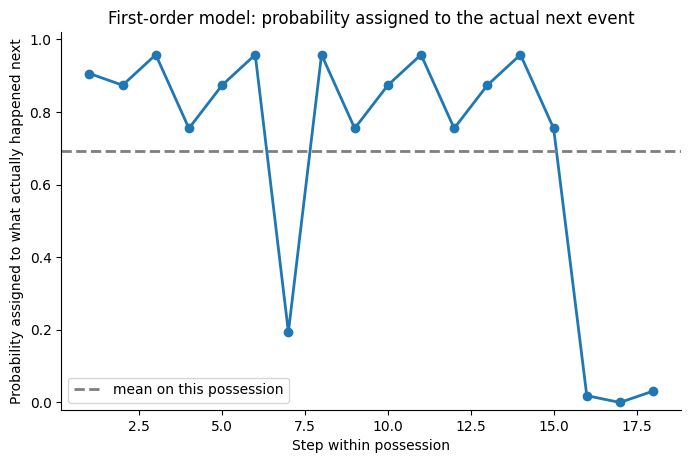

In [10]:
fig, ax = plt.subplots(figsize=(8, 5),dpi=100)
ax.plot(
    walk_df["step"],
    walk_df["p(actual_next)"],
    marker="o",
    linewidth=2,
    color=COLOR_MAIN,
)
ax.axhline(
    walk_df["p(actual_next)"].mean(),
    linestyle="--",
    linewidth=2,
    color=COLOR_REFERENCE,
    label="mean on this possession",
)
ax.set_title("First-order model: probability assigned to the actual next event")
ax.set_xlabel("Step within possession")
ax.set_ylabel("Probability assigned to what actually happened next")
ax.set_ylim(-0.02, 1.02)
ax.legend()


plt.show()

A few steps look exactly like the possession grammar the model has learned: `Ball Recovery -> Carry -> Pass -> Ball Receipt* -> Carry`. The assigned probabilities are high and the model looks smart.

Then the possession branches.

At one point `Ball Receipt*` is followed immediately by `Pass` rather than `Carry`. The model still gives that a reasonable chance, but not its top guess. Later, a `Carry` turns into a `Shot`, which the first-order model thinks is possible but unlikely. And then the big miss: after `Shot`, the next event is `Ball Recovery`, which this training sample never saw from that state at all.

That is the right setup for log-loss.


## 5. Why not just percentage correct?

Suppose we have two models and both guess the right event.

- Model A says the true event has probability $0.51$.
- Model B says the true event has probability $0.95$.

If we only score "right" versus "wrong", those two predictions look identical. But they are not identical at all. Model B was much sharper *and* correct.

Now flip it around.

- Model C says the true event has probability $0.01$ and is very confident in the wrong outcome.
- Model D says the true event has probability $0.30$ and was unsure.

Both are wrong in a top-1 sense, but Model C deserves a much harsher penalty.

So accuracy throws away the part of the prediction that we actually care about: the *probability distribution*.


In [11]:
toy_predictions = pd.DataFrame(
    {
        "scenario": [
            "Correct but barely",
            "Correct and confident",
            "Wrong and unsure",
            "Wrong and wildly confident",
        ],
        "probability_assigned_to_true_event": [0.51, 0.95, 0.30, 0.01],
    }
)

toy_predictions["top1_correct?"] = ["yes", "yes", "no", "no"]
toy_predictions["log_loss_nats"] = -np.log(toy_predictions["probability_assigned_to_true_event"])
toy_predictions["log_loss_bits"] = toy_predictions["log_loss_nats"] / np.log(2)

display(toy_predictions.round(4))


,scenario,probability_assigned_to_true_event,top1_correct?,log_loss_nats,log_loss_bits
0,Correct but barely,0.51,yes,0.6733,0.9714
1,Correct and confident,0.95,yes,0.0513,0.0740
2,Wrong and unsure,0.30,no,1.2040,1.7370
3,Wrong and wildly confident,0.01,no,4.6052,6.6439


Recall our friend, the **log-loss**!

For held-out next-event predictions, if $q_t(x_t)$ is the probability our model assigned to the event that actually happened at step $t$, then the mean log-loss is

$$
L = -\frac{1}{N} \sum_{t=1}^{N} \log q_t(x_t),
$$

where:

- $N$ is the number of scored transitions,
- $x_t$ is the observed next event at step $t$,
- $q_t(x_t)$ is the model's assigned probability to that observed event.

This form makes sense.

- If the model assigns a probability near $1$, then $-\log q_t(x_t)$ is near $0$, which is good.
- If the model assigns a moderate probability, the penalty is moderate.
- If the model assigns a probability near $0$, the penalty blows up.

That is exactly the behavior we want from a probabilistic scoring rule.

We will also use two equivalent summaries:

$$
L_{\text{bits}} = \frac{L}{\ln 2},
$$

and

$$
\text{perplexity} = \exp(L).
$$

Perplexity gives a nice rough interpretation: the model is about as confused as if it were choosing among that many equally likely options.


A subtle but important detail: the logarithm base only changes the units. Natural logs give **nats**. Base-2 logs give **bits**. The ranking of models is the same either way.


## 6. Scoring the first-order model on held-out possessions

Now we do the honest thing. Fit the transition matrix on the training possessions, then score how much probability it assigns to the *actual* next events in the held-out possessions.


In [12]:
first_order_score = score_next_event_model(
    test_sequences,
    predict_first_order,
    states=states,
    state_to_idx=state_to_idx,
    min_context_len=1,
)

first_order_summary = pd.DataFrame(
    {
        "metric": ["transitions scored", "mean log-loss (nats)", "mean log-loss (bits)", "perplexity"],
        "value": [
            first_order_score["n_transitions"],
            first_order_score["mean_log_loss_nats"],
            first_order_score["mean_log_loss_bits"],
            first_order_score["perplexity"],
        ],
    }
)
display(first_order_summary.round(4))

zero_prob_count = int((first_order_score["details"]["prob_true_raw"] == 0).sum())
print(f"Zero-probability hits on the holdout set: {zero_prob_count} of {first_order_score['n_transitions']}")


,metric,value
0,transitions scored,447.0000
1,mean log-loss (nats),1.1144
2,mean log-loss (bits),1.6078
3,perplexity,3.0479


Zero-probability hits on the holdout set: 7 of 447


A perplexity a little above $3$ is not bad at all for a 17-state prediction problem. The model is clearly learning real structure.

But that number by itself is hard to interpret. Is $3.05$ impressive? Maybe. Maybe not.

So now we do what every predictive modeling workflow should do next: build baselines.


## 7. Prediction-vs-actual for the first-order model

Before we leave the first-order model, it helps to look at its top-1 behavior. This is *not* our main scoring rule, but it tells us what kinds of mistakes the model tends to make.


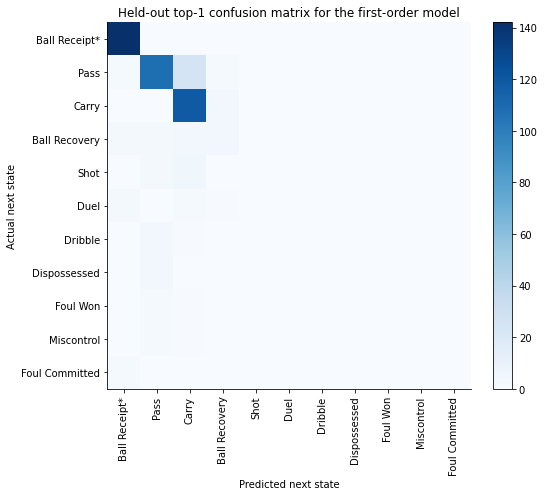

In [13]:
first_order_predictions = collect_predictions(
    test_sequences,
    predict_first_order,
    states=states,
    state_to_idx=state_to_idx,
    min_context_len=1,
)

state_order_by_test_freq = (
    first_order_predictions["true_next_state"]
    .value_counts()
    .index
    .tolist()
)

confusion = pd.crosstab(
    first_order_predictions["true_next_state"],
    first_order_predictions["predicted_next_state"],
)

confusion = confusion.reindex(index=state_order_by_test_freq, columns=state_order_by_test_freq, fill_value=0)
plot_heatmap(
    confusion,
    title="Held-out top-1 confusion matrix for the first-order model",
    xlabel="Predicted next state",
    ylabel="Actual next state",
    cmap="Blues",
    annotate=False,
    figsize=(8, 7),
)


### Reading the Confusion Matrix

This heatmap shows **what the model predicted** (x-axis) versus **what actually happened** (y-axis) for each transition in the held-out set.

- **Dark squares on the diagonal** mean the model's top-1 guess matched reality — that's correct prediction.
- **Dark squares off the diagonal** are systematic errors — the model consistently confuses one event for another.

In [14]:
top_mismatches = (
    first_order_predictions.loc[
        first_order_predictions["true_next_state"] != first_order_predictions["predicted_next_state"]
    ]
    .groupby(["true_next_state", "predicted_next_state"])
    .size()
    .sort_values(ascending=False)
    .rename("count")
    .reset_index()
)

display(top_mismatches.head(12))


,true_next_state,predicted_next_state,count
0,Pass,Carry,25
1,Shot,Carry,5
2,Ball Recovery,Carry,4
3,Carry,Ball Recovery,4
4,Dispossessed,Pass,4
5,Dribble,Pass,4
6,Ball Recovery,Ball Receipt*,3
7,Shot,Pass,3
8,Duel,Ball Receipt*,3
9,Ball Recovery,Pass,3


### What the mismatch table shows

The model defaults to the most common successor for each state, so its mistakes are predictable:

| Pattern | Why it happens |
|---|---|
| **Pass → Carry** (25 errors) | The model always predicts the most likely next event after a pass (Ball Receipt*), but sometimes the possession skips straight to a carry or something else entirely. |
| **Shot → Carry** (5) | Shots can lead to many outcomes (goal kick, corner, rebound). The model picks the single likeliest one and gets it wrong when the possession branches. |
| **Carry → Ball Recovery / Shot** | Carries are a crossroads — dribble, pass, shoot, lose it. A first-order model only sees "Carry" and has to guess, with no memory of how the team got there. |

### The takeaway

A first-order Markov model knows the single most probable next event from each state, which works well for dominant transitions like Pass → Ball Receipt*. It fails at **branching points** where the correct next event depends on earlier context the model can't see. That's the "memory-limited" problem — and the motivation for trying higher-order or baseline models next.

The main pattern is exactly what we would expect from the transition matrix:

- `Pass -> Ball Receipt*` is easy and dominant.
- `Ball Receipt* -> Carry` is the model's favorite continuation.
- The hard spots come when a possession branches sharply: `Carry -> Shot`, `Ball Receipt* -> Pass`, and unusual post-shot transitions.

So the first-order model is not dumb. It is just memory-limited.


### Your turn!

Pick a different held-out possession and run the same walk-through.

Good candidates are possessions that end in a shot or a turnover. Where does the model look impressively confident? Where does it look overconfident for the wrong reason?


In [15]:
# Your turn:
# Try a different possession number from test_meta["possession"] and re-run the walk-through.

# candidate_possession = int(test_meta["possession"].iloc[0])
# candidate_events = argentina_df.loc[argentina_df["possession"] == candidate_possession].copy()
# candidate_sequence = candidate_events["state"].tolist()
# print(" -> ".join(candidate_sequence))


In [16]:
import networkx as nx

In [17]:
# Build the directed graph from the transition matrix
# `P1` should be your (states x states) numpy array of probabilities
# `states` is your list of state names

G = nx.DiGraph()

for i, src in enumerate(states):
    for j, dst in enumerate(states):
        weight = P1[i, j]
        if weight > 0.01:  # drop negligible edges to reduce clutter
            G.add_edge(src, dst, weight=weight)

In [18]:
# --- layout ---
pos = nx.spring_layout(G, k=2.2, iterations=500, seed=5442)

# --- edge visuals scaled by weight ---
edges = G.edges(data=True)
weights = np.array([d["weight"] for _, _, d in edges])
edge_widths = 0.5 + 5 * (weights / weights.max())
edge_alphas = 0.5 + 0.5 * (weights / weights.max())

# --- node sizes scaled by out-degree (weighted) ---
out_strength = dict(G.out_degree(weight="weight"))
node_sizes = [300 + 1000 * out_strength.get(n, 0) / max(out_strength.values()) for n in G.nodes()]

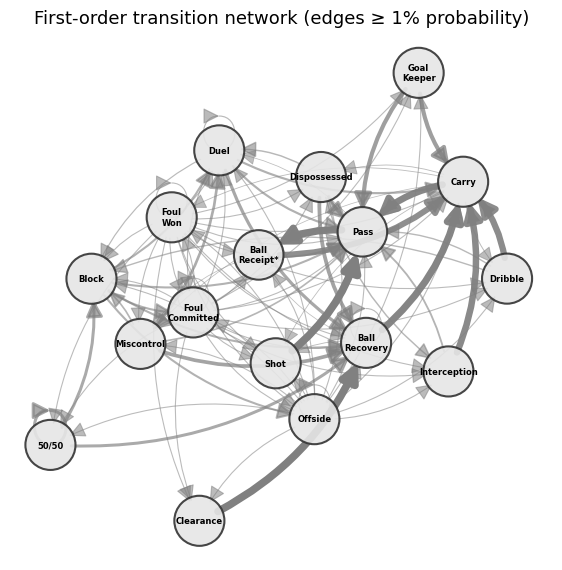

In [19]:
fig, ax = plt.subplots(figsize=(7, 7),dpi=100)

nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_size=node_sizes,
    node_color="0.9",
    edgecolors=".2",
    linewidths=1.5,
    alpha=0.9,
)

# draw edges one by one so each can have its own alpha
for (u, v, d), w, a in zip(edges, edge_widths, edge_alphas):
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edgelist=[(u, v)],
        width=w,
        alpha=a,
        edge_color="gray",
        arrows=True,
        arrowsize=25,
        connectionstyle="arc3,rad=0.2",
        min_source_margin=15,
        min_target_margin=15,
    )

nx.draw_networkx_labels(G, pos, labels=dict(zip(G.nodes(),[i.replace(' ','\n') for i in G.nodes()])),
                        ax=ax, font_size=6, font_weight="bold")

ax.set_title("First-order transition network (edges ≥ 1% probability)", fontsize=13)
ax.axis("off")

plt.show()

## 7A. What survives if we rewire the transition network?

Before we leave the plain first-order transition matrix, there is a nice network-science question hiding in plain sight.

How much predictive power survives if we scramble some fraction of the learned event-to-event structure?

We want that perturbation to be controlled, not arbitrary. So we will work at the level of individual observed transition tokens in the training data. Every observed pair such as `Carry -> Pass` is one token. Then, for a chosen rewiring fraction $r$:

- keep the **source state** of every token fixed,
- choose an $r$ fraction of the tokens,
- randomly **permute their target states** among those selected tokens.

That means the experiment preserves:

- the same state space,
- the same total number of transition observations,
- the same number of outgoing transitions from each source state,
- and the same overall frequency of target states.

What gets broken is the specific pairing between source and target.

So this is a pretty clean null model. If performance collapses quickly, then the exact learned edges are doing a lot of work. If performance decays slowly, then a good chunk of the predictive signal is living in broader marginals and dominant transition families rather than in fragile individual edges.


In [20]:
transition_token_table = pd.DataFrame(
    [(a, b) for seq in train_sequences for a, b in zip(seq[:-1], seq[1:])],
    columns=["source", "target"],
)
print(f"Transition tokens in training: {len(transition_token_table):,}")
display(transition_token_table.head(10))

def counts_from_transition_tokens(token_table, states):
    counts = np.zeros((len(states), len(states)), dtype=float)
    lookup = {state: i for i, state in enumerate(states)}
    for row in token_table.itertuples(index=False):
        counts[lookup[row.source], lookup[row.target]] += 1
    return counts

def predictor_from_counts(counts, states, state_to_idx):
    P = row_normalize(counts)

    def predict(context):
        return P[state_to_idx[context[-1]]]

    return predict

def rewire_transition_tokens(token_table, nominal_fraction, rng, n_shuffle_tries=12):
    rewired = token_table.copy()
    n_tokens = len(rewired)
    n_selected = int(round(nominal_fraction * n_tokens))

    if n_selected <= 1:
        return rewired, 0.0

    selected = rng.choice(n_tokens, size=n_selected, replace=False)
    target_col = rewired.columns.get_loc("target")
    original_targets = rewired.iloc[selected, target_col].to_numpy(copy=True)

    best_targets = original_targets.copy()
    best_changed = 0

    for _ in range(n_shuffle_tries):
        candidate = rng.permutation(original_targets)
        changed = int(np.sum(candidate != original_targets))
        if changed > best_changed:
            best_targets = candidate.copy()
            best_changed = changed
            if best_changed == n_selected:
                break

    rewired.iloc[selected, target_col] = best_targets
    effective_fraction = best_changed / n_tokens
    return rewired, effective_fraction

rewire_levels = [0.01, 0.02, 0.03, 0.05, 0.10, 0.20, 0.35, 0.50]
n_rewire_trials = 50
rewire_rows = []

for nominal_fraction in rewire_levels:
    for trial in range(n_rewire_trials):
        rng_rewire = np.random.default_rng(SEED + 1000 * trial + int(10000 * nominal_fraction))
        rewired_tokens, effective_fraction = rewire_transition_tokens(
            transition_token_table,
            nominal_fraction=nominal_fraction,
            rng=rng_rewire,
        )
        rewired_counts = counts_from_transition_tokens(rewired_tokens, states)
        rewired_predict = predictor_from_counts(rewired_counts, states, state_to_idx)
        rewired_score = score_next_event_model(
            test_sequences,
            rewired_predict,
            states=states,
            state_to_idx=state_to_idx,
            min_context_len=1,
        )
        rewire_rows.append(
            {
                "nominal_rewire_fraction": nominal_fraction,
                "effective_rewire_fraction": effective_fraction,
                "trial": trial,
                "log_loss_nats": rewired_score["mean_log_loss_nats"],
                "perplexity": rewired_score["perplexity"],
            }
        )

rewire_results = pd.DataFrame(rewire_rows)

rewire_summary = (
    rewire_results.groupby("nominal_rewire_fraction")
    .agg(
        mean_effective_rewire_fraction=("effective_rewire_fraction", "mean"),
        mean_log_loss_nats=("log_loss_nats", "mean"),
        sd_log_loss_nats=("log_loss_nats", "std"),
        mean_perplexity=("perplexity", "mean"),
        sd_perplexity=("perplexity", "std"),
    )
    .reset_index()
)

rewire_summary_display = rewire_summary.copy()
rewire_summary_display["nominal_rewire_pct"] = 100 * rewire_summary_display["nominal_rewire_fraction"]
rewire_summary_display["effective_rewire_pct"] = 100 * rewire_summary_display["mean_effective_rewire_fraction"]

display(
    rewire_summary_display[
        [
            "nominal_rewire_pct",
            "effective_rewire_pct",
            "mean_log_loss_nats",
            "sd_log_loss_nats",
            "mean_perplexity",
            "sd_perplexity",
        ]
    ].round(4)
)


Transition tokens in training: 1,374


,source,target
0,Pass,Ball Receipt*
1,Ball Receipt*,Carry
2,Carry,Foul Won
3,Pass,Ball Receipt*
4,Ball Receipt*,Carry
5,Carry,Pass
6,Pass,Ball Receipt*
7,Ball Receipt*,Carry
8,Carry,Pass
9,Pass,Ball Receipt*


,nominal_rewire_pct,effective_rewire_pct,mean_log_loss_nats,sd_log_loss_nats,mean_perplexity,sd_perplexity
0,1.0,0.8675,1.1103,0.0362,3.0370,0.1005
1,2.0,1.6143,1.1099,0.0412,3.0366,0.1261
2,3.0,2.4178,1.0984,0.0384,3.0014,0.1134
3,5.0,3.9461,1.1052,0.0628,3.0257,0.1910
4,10.0,7.7336,1.1291,0.0728,3.1011,0.2303
5,20.0,15.1936,1.1747,0.1002,3.2537,0.3386
6,35.0,26.2999,1.2921,0.1109,3.6633,0.4341
7,50.0,37.3421,1.4935,0.1389,4.4964,0.6628


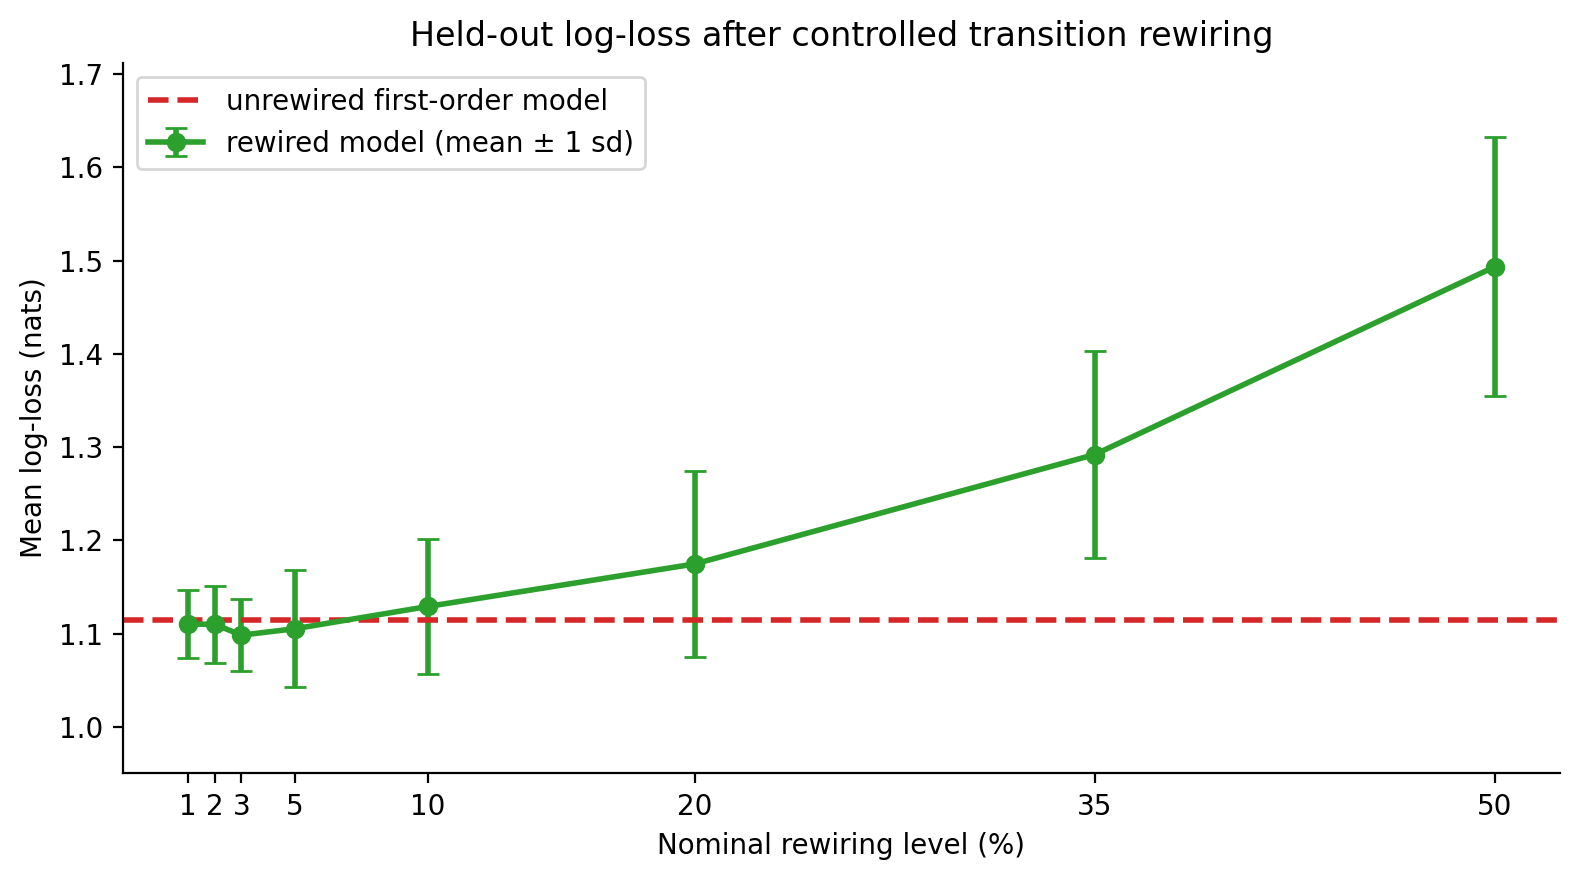

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5),dpi=200)
x = 100 * rewire_summary["nominal_rewire_fraction"]

ax.errorbar(
    x,
    rewire_summary["mean_log_loss_nats"],
    yerr=rewire_summary["sd_log_loss_nats"],
    color=COLOR_SECOND,
    marker="o",
    linewidth=2,
    capsize=4,
    label="rewired model (mean ± 1 sd)",
)
ax.axhline(
    first_order_score["mean_log_loss_nats"],
    color=COLOR_BASELINE,
    linestyle="--",
    linewidth=2,
    label="unrewired first-order model",
)
ax.set_title("Held-out log-loss after controlled transition rewiring")
ax.set_xlabel("Nominal rewiring level (%)")
ax.set_ylabel("Mean log-loss (nats)")
ax.set_xticks(x)
ax.set_ylim(
    0.95,
    max(rewire_summary["mean_log_loss_nats"] + rewire_summary["sd_log_loss_nats"]) + 0.08,
)
ax.legend()
fig.tight_layout()
plt.show()


A nice subtle point: the first few rewiring levels barely move the score, and a few trials even improve it slightly. That is not a bug. Tiny perturbations can accidentally smooth one or two overfit rows.

But once we start scrambling a serious chunk of the pairings, the held-out score gets worse and the spread across trials widens. So the transition network is **not maximally brittle**. A little rewiring does not destroy it. Still, it is not just a base-rate machine either. By the time we scramble a third to a half of the token-level pairings, a lot of the predictive advantage has leaked away.

One more detail worth noticing: the *effective* rewiring percentage is a bit below the nominal one, because some target labels repeat. That is fine. The source counts and global target marginals are still preserved exactly, which is the whole point of this perturbation.


In [22]:
def build_transition_digraph(P, states, min_weight=0.01):
    """Build a weighted DiGraph from a row-normalised transition matrix."""
    G = nx.DiGraph()
    for i, src in enumerate(states):
        for j, dst in enumerate(states):
            w = P[i, j]
            if w > min_weight:
                G.add_edge(src, dst, weight=w)
    return G

In [23]:
# --- shared layout from the original graph so positions stay comparable ---
pos = nx.spring_layout(G, k=2.2, iterations=500, seed=5442)

def draw_transition_network(G, pos, ax, title):
    edges = list(G.edges(data=True))
    if not edges:
        return
    weights = np.array([d["weight"] for _, _, d in edges])
    edge_widths = 0.5 + 5 * (weights / weights.max())
    edge_alphas = 0.25 + 0.75 * (weights / weights.max())

    out_strength = dict(G.out_degree(weight="weight"))
    max_out = max(out_strength.values()) if out_strength else 1
    node_sizes = [300 + 1800 * out_strength.get(n, 0) / max_out for n in G.nodes()]

    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_sizes,
        node_color=".9",
        edgecolors=".2",
        linewidths=1.5,
        alpha=0.9,
    )
    for (u, v, d), w, a in zip(edges, edge_widths, edge_alphas):
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            edgelist=[(u, v)],
            width=w,
            alpha=a,
            edge_color="gray",
            arrows=True,
            arrowsize=12,
            connectionstyle="arc3,rad=0.2",
            min_source_margin=15,
            min_target_margin=15,
        )

    nx.draw_networkx_labels(G, pos, labels=dict(zip(G.nodes(),[i.replace(' ','\n') for i in G.nodes()])),
                        ax=ax, font_size=6, font_weight="bold")

    ax.set_title(title, fontsize=11)
    ax.axis("off")

In [24]:
# --- original network ---
G_orig = build_transition_digraph(P1, states)

# --- one 35%-rewired network (pick a single trial for illustration) ---
rng_vis = np.random.default_rng(SEED + 9999)
rewired_tokens_vis, eff_frac_vis = rewire_transition_tokens(
    transition_token_table, nominal_fraction=0.35, rng=rng_vis,
)

rewired_counts_vis = counts_from_transition_tokens(rewired_tokens_vis, states)
P_rewired_vis = row_normalize(rewired_counts_vis)
G_rewired = build_transition_digraph(P_rewired_vis, states)

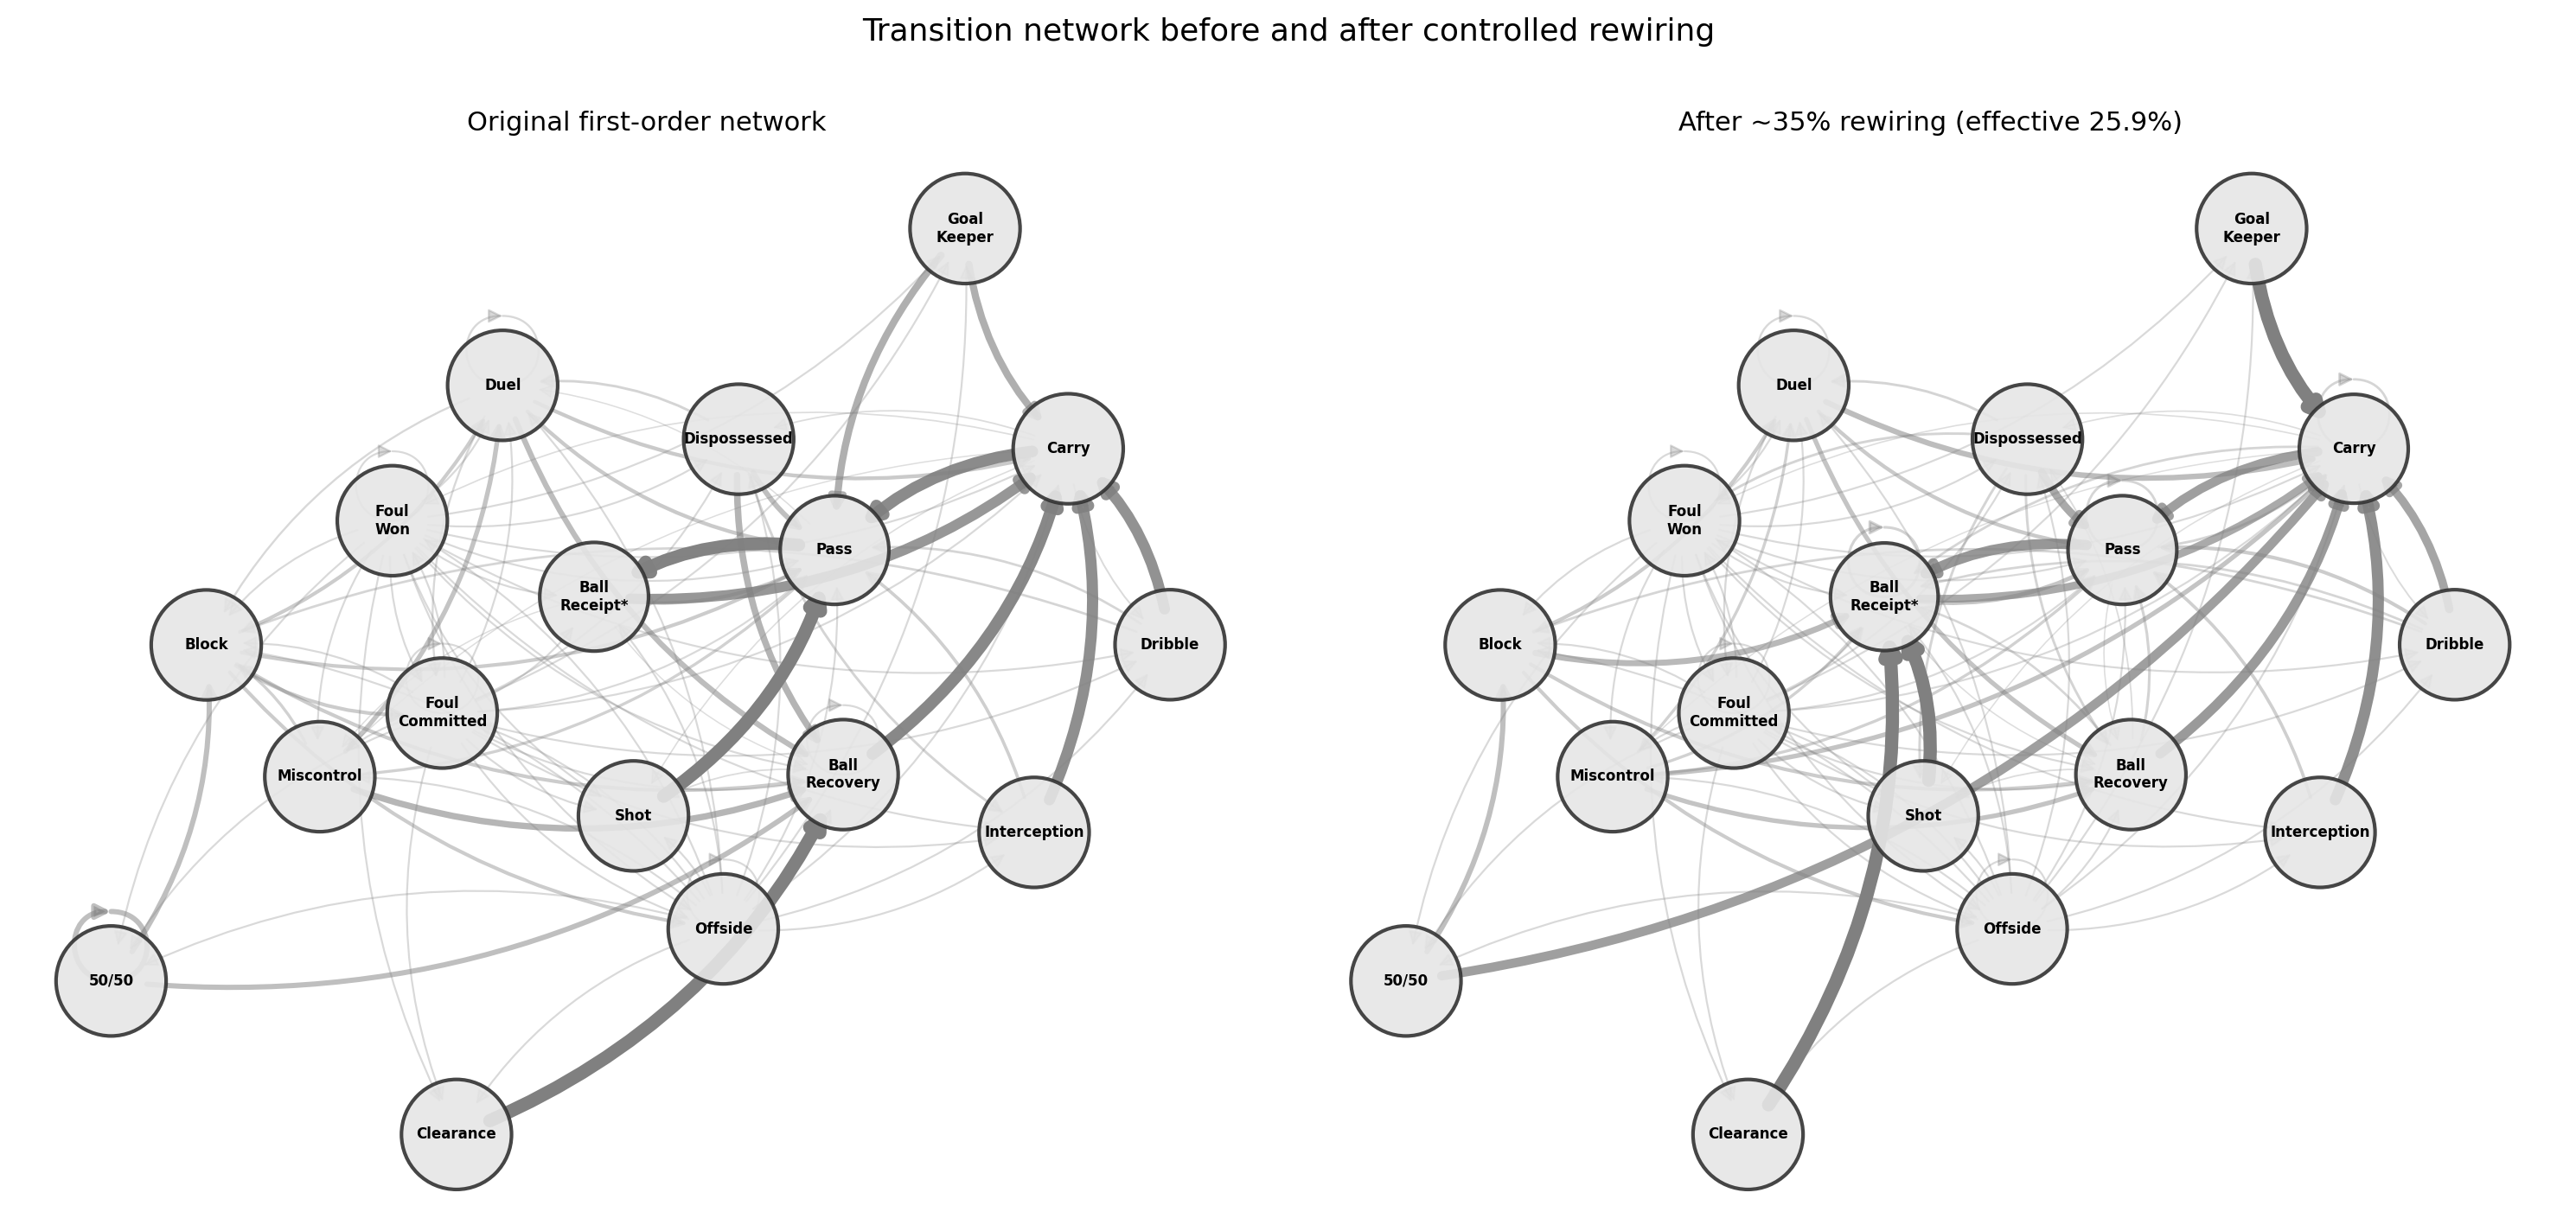

Original graph:  97 edges  (>1% threshold)
Rewired graph:   102 edges  (>1% threshold)


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7), dpi=200)

draw_transition_network(G_orig, pos, axes[0],
    "Original first-order network")
draw_transition_network(G_rewired, pos, axes[1],
    f"After ~35% rewiring (effective {eff_frac_vis:.1%})")

fig.suptitle(
    "Transition network before and after controlled rewiring",
    fontsize=13, y=1.01,
)
fig.tight_layout()
plt.show()

# --- quick edge-count comparison ---
print(f"Original graph:  {G_orig.number_of_edges()} edges  "
      f"(>{0.01:.0%} threshold)")
print(f"Rewired graph:   {G_rewired.number_of_edges()} edges  "
      f"(>{0.01:.0%} threshold)")

## Your turn! 

Using your networkx approach, span a series of degree-preserving and non-degree-preserving randomizations.

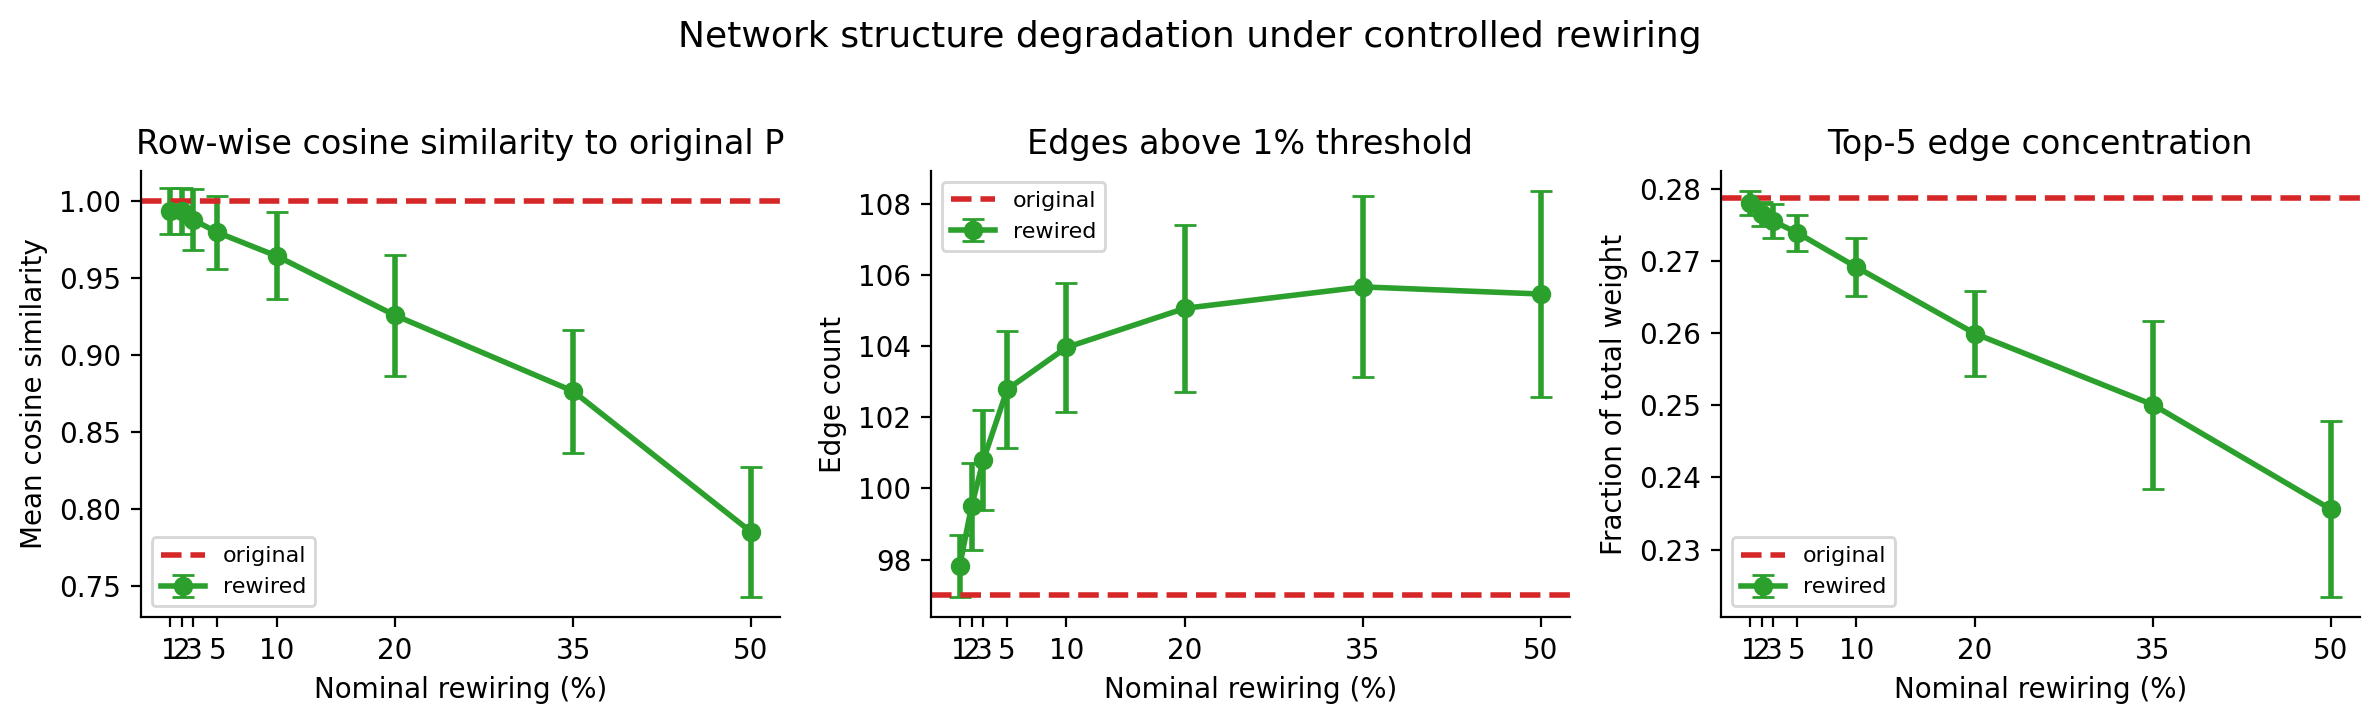

In [26]:
from numpy.linalg import norm

def row_cosine_similarity(P_orig, P_other):
    """Mean cosine similarity between corresponding rows of two transition matrices."""
    sims = []
    for i in range(P_orig.shape[0]):
        a, b = P_orig[i], P_other[i]
        denom = norm(a) * norm(b)
        sims.append(np.dot(a, b) / denom if denom > 0 else 1.0)
    return np.mean(sims)

def edges_above_threshold(P, threshold=0.01):
    return int(np.sum(P > threshold))

def backbone_concentration(P, top_k=5):
    flat = P.ravel()
    top_k_weight = np.sort(flat)[-top_k:].sum()
    return top_k_weight / flat.sum()

# --- sweep: recompute graph metrics for the same trials ---
graph_metric_rows = []

for nominal_fraction in rewire_levels:
    for trial in range(n_rewire_trials):
        rng_rewire = np.random.default_rng(SEED + 1000 * trial + int(10000 * nominal_fraction))
        rewired_tokens, eff_frac = rewire_transition_tokens(
            transition_token_table, nominal_fraction=nominal_fraction, rng=rng_rewire,
        )
        rewired_counts = counts_from_transition_tokens(rewired_tokens, states)
        P_rw = row_normalize(rewired_counts)

        graph_metric_rows.append({
            "nominal_rewire_fraction": nominal_fraction,
            "trial": trial,
            "cosine_sim": row_cosine_similarity(P1, P_rw),
            "n_edges": edges_above_threshold(P_rw),
            "backbone_conc": backbone_concentration(P_rw, top_k=5),
        })

graph_metrics = pd.DataFrame(graph_metric_rows)

graph_summary = (
    graph_metrics.groupby("nominal_rewire_fraction")
    .agg(
        mean_cosine=("cosine_sim", "mean"),
        sd_cosine=("cosine_sim", "std"),
        mean_edges=("n_edges", "mean"),
        sd_edges=("n_edges", "std"),
        mean_backbone=("backbone_conc", "mean"),
        sd_backbone=("backbone_conc", "std"),
    )
    .reset_index()
)

# --- original baselines ---
orig_cosine = 1.0
orig_edges = edges_above_threshold(P1)
orig_backbone = backbone_concentration(P1, top_k=5)

# --- three-panel figure ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), dpi=200)
x = 100 * graph_summary["nominal_rewire_fraction"]

# Panel 1: cosine similarity
ax = axes[0]
ax.errorbar(x, graph_summary["mean_cosine"], yerr=graph_summary["sd_cosine"],
            color=COLOR_SECOND, marker="o", linewidth=2, capsize=4, label="rewired")
ax.axhline(orig_cosine, color=COLOR_BASELINE, linestyle="--", linewidth=2, label="original")
ax.set_title("Row-wise cosine similarity to original P")
ax.set_xlabel("Nominal rewiring (%)")
ax.set_ylabel("Mean cosine similarity")
ax.set_xticks(x)
ax.set_ylim(None, 1.02)
ax.legend(fontsize=8)

# Panel 2: edge count
ax = axes[1]
ax.errorbar(x, graph_summary["mean_edges"], yerr=graph_summary["sd_edges"],
            color=COLOR_SECOND, marker="o", linewidth=2, capsize=4, label="rewired")
ax.axhline(orig_edges, color=COLOR_BASELINE, linestyle="--", linewidth=2, label="original")
ax.set_title("Edges above 1% threshold")
ax.set_xlabel("Nominal rewiring (%)")
ax.set_ylabel("Edge count")
ax.set_xticks(x)
ax.legend(fontsize=8)

# Panel 3: backbone concentration
ax = axes[2]
ax.errorbar(x, graph_summary["mean_backbone"], yerr=graph_summary["sd_backbone"],
            color=COLOR_SECOND, marker="o", linewidth=2, capsize=4, label="rewired")
ax.axhline(orig_backbone, color=COLOR_BASELINE, linestyle="--", linewidth=2, label="original")
ax.set_title("Top-5 edge concentration")
ax.set_xlabel("Nominal rewiring (%)")
ax.set_ylabel("Fraction of total weight")
ax.set_xticks(x)
ax.legend(fontsize=8)

fig.suptitle("Network structure degradation under controlled rewiring", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# Part II — Baselines and better context

## 8. Baselines: what does "good" mean here?

A prediction score is only meaningful relative to a baseline.

We will compare the first-order model against two very simple competitors.

- **Uniform baseline:** every next state gets probability $1 / 17$.
- **Marginal baseline:** ignore the current state and always predict the overall next-state frequency distribution from the training data.

These are deliberately weak. Good. Weak baselines are still useful because they tell us how much structure is already present in base rates alone.


In [27]:
uniform_probs = np.full(len(states), 1 / len(states), dtype=float)
marginal_probs = marginal_distribution(train_sequences, states)

def predict_uniform(context):
    return uniform_probs

def predict_marginal(context):
    return marginal_probs

uniform_score = score_next_event_model(
    test_sequences,
    predict_uniform,
    states=states,
    state_to_idx=state_to_idx,
    min_context_len=1,
)

marginal_score = score_next_event_model(
    test_sequences,
    predict_marginal,
    states=states,
    state_to_idx=state_to_idx,
    min_context_len=1,
)

baseline_summary = pd.DataFrame(
    [
        {
            "model": "Uniform",
            "transitions_scored": uniform_score["n_transitions"],
            "log_loss_nats": uniform_score["mean_log_loss_nats"],
            "log_loss_bits": uniform_score["mean_log_loss_bits"],
            "perplexity": uniform_score["perplexity"],
        },
        {
            "model": "Marginal",
            "transitions_scored": marginal_score["n_transitions"],
            "log_loss_nats": marginal_score["mean_log_loss_nats"],
            "log_loss_bits": marginal_score["mean_log_loss_bits"],
            "perplexity": marginal_score["perplexity"],
        },
        {
            "model": "First-order Markov",
            "transitions_scored": first_order_score["n_transitions"],
            "log_loss_nats": first_order_score["mean_log_loss_nats"],
            "log_loss_bits": first_order_score["mean_log_loss_bits"],
            "perplexity": first_order_score["perplexity"],
        },
    ]
).sort_values("log_loss_nats")

display(baseline_summary.round(4))


,model,transitions_scored,log_loss_nats,log_loss_bits,perplexity
2,First-order Markov,447,1.1144,1.6078,3.0479
1,Marginal,447,1.5241,2.1988,4.5910
0,Uniform,447,2.8332,4.0875,17.0000


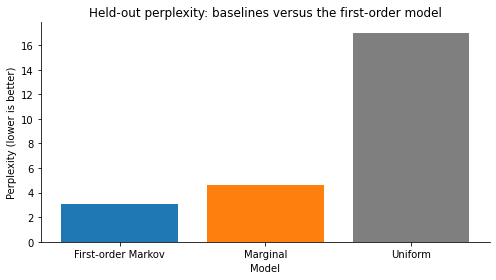

In [28]:
baseline_bar_colors = baseline_summary["model"].map(
    {
        "Uniform": COLOR_REFERENCE,
        "Marginal": COLOR_ACCENT,
        "First-order Markov": COLOR_MAIN,
    }
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(baseline_summary["model"], baseline_summary["perplexity"], color=baseline_bar_colors)
ax.set_title("Held-out perplexity: baselines versus the first-order model")
ax.set_xlabel("Model")
ax.set_ylabel("Perplexity (lower is better)")
fig.tight_layout()
plt.show()


This is the first clear payoff.

The uniform model is completely lost. Its perplexity is basically $17$, which makes sense: that is exactly the number of coarse states.

The marginal model is much better, which tells us base rates already matter a lot. `Pass`, `Ball Receipt*`, and `Carry` are simply more common than `Shot`, `Goal Keeper`, or `Offside`.

Then the first-order model improves again by conditioning on the current state. So the ladder really is

**uniform -> marginal -> first-order Markov**.

Now the obvious next question is whether more memory helps.


## 9. Second-order prediction: the previous two states matter

A first-order model says

$$
\Pr(X_{t+1} = x \mid X_t).
$$

A second-order model says

$$
\Pr(X_{t+1} = x \mid X_{t-1}, X_t).
$$

That extra piece of memory matters whenever the same current state behaves differently depending on where it came from.

Class 16 hinted at exactly one example. Now we make it the star of the show.


In [29]:
second_order_context_counts = Counter()
second_order_transition_counts = Counter()

for seq in train_sequences:
    for a, b, c in zip(seq[:-2], seq[1:-1], seq[2:]):
        second_order_context_counts[(a, b)] += 1
        second_order_transition_counts[(a, b, c)] += 1

def second_order_distribution(prev_prev, prev, states):
    total = second_order_context_counts.get((prev_prev, prev), 0)
    probs = np.zeros(len(states), dtype=float)
    if total == 0:
        return probs
    for state in states:
        probs[state_to_idx[state]] = second_order_transition_counts.get((prev_prev, prev, state), 0) / total
    return probs

carry_after_recovery = pd.Series(
    second_order_distribution("Ball Recovery", "Carry", states),
    index=states,
).sort_values(ascending=False)

carry_after_receipt = pd.Series(
    second_order_distribution("Ball Receipt*", "Carry", states),
    index=states,
).sort_values(ascending=False)

carry_context_table = pd.DataFrame(
    {
        "first_order_from_Carry": transition_df.loc["Carry"],
        "second_order_from_(Ball Recovery, Carry)": pd.Series(
            second_order_distribution("Ball Recovery", "Carry", states), index=states
        ),
        "second_order_from_(Ball Receipt*, Carry)": pd.Series(
            second_order_distribution("Ball Receipt*", "Carry", states), index=states
        ),
    }
).sort_values("second_order_from_(Ball Receipt*, Carry)", ascending=False)

display(carry_context_table.head(8).round(4))
print("Training counts:")
print(f"(Ball Recovery, Carry): {second_order_context_counts[('Ball Recovery', 'Carry')]}")
print(f"(Ball Receipt*, Carry): {second_order_context_counts[('Ball Receipt*', 'Carry')]}")


,first_order_from_Carry,"second_order_from_(Ball Recovery, Carry)","second_order_from_(Ball Receipt*, Carry)"
Pass,0.8740,0.931,0.8685
Dribble,0.0429,0.000,0.0489
Foul Won,0.0241,0.000,0.0245
Dispossessed,0.0295,0.069,0.0245
Shot,0.0188,0.000,0.0214
Miscontrol,0.0107,0.000,0.0122
Offside,0.0000,0.000,0.0000
Interception,0.0000,0.000,0.0000


Training counts:
(Ball Recovery, Carry): 29
(Ball Receipt*, Carry): 327


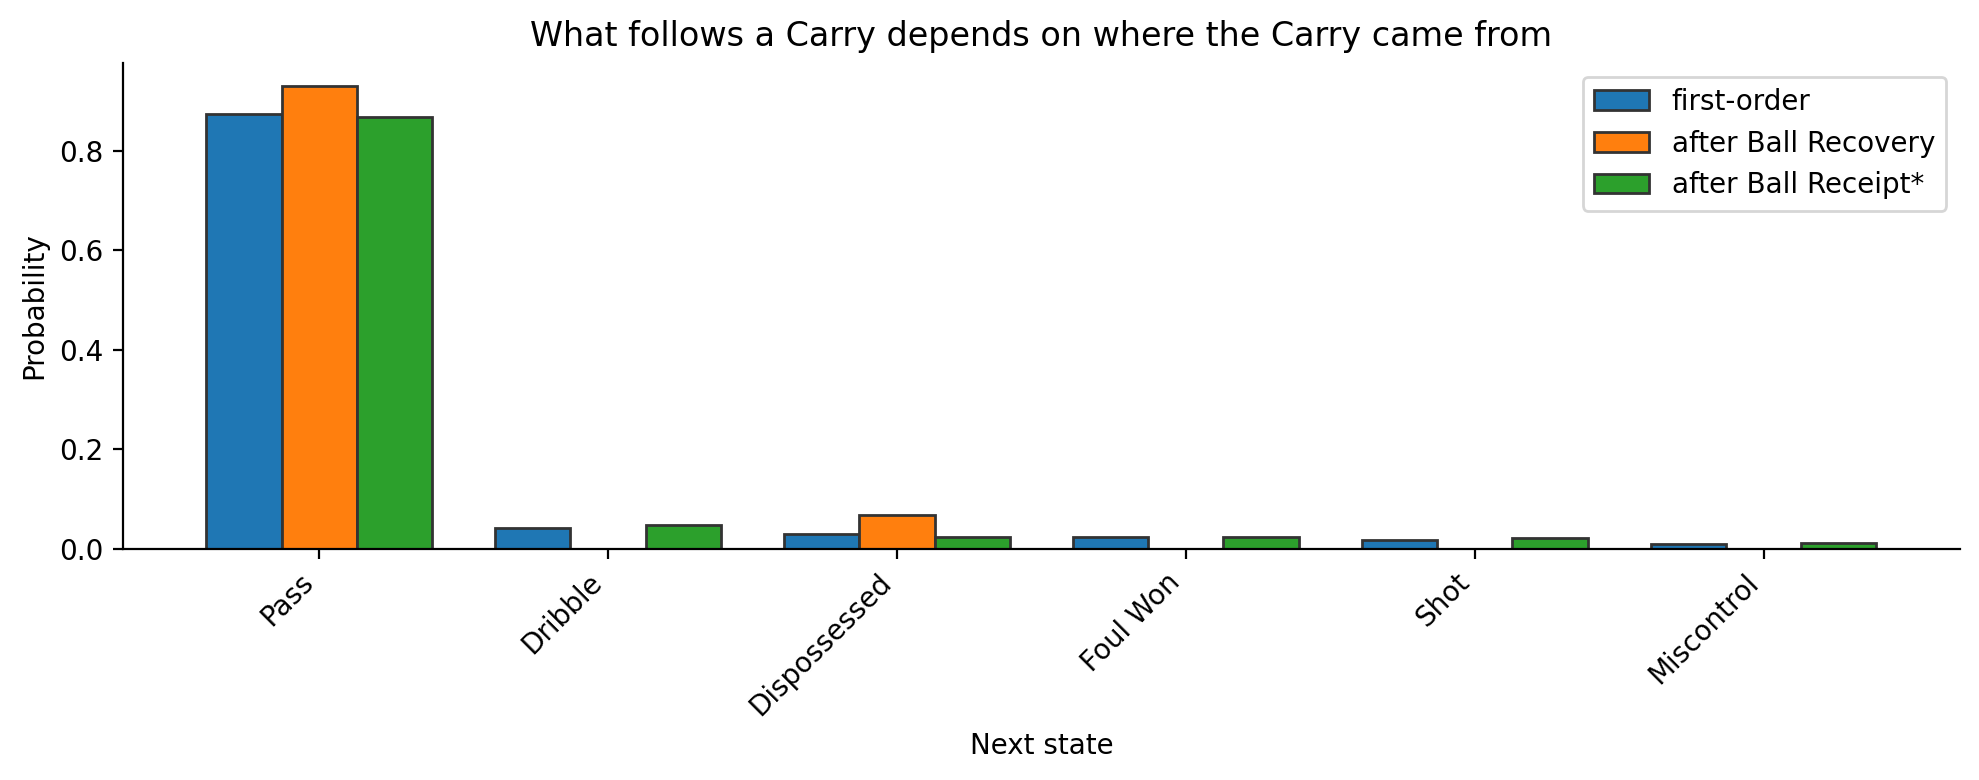

In [30]:
top_states_for_carry = ["Pass", "Dribble", "Dispossessed", "Foul Won", "Shot", "Miscontrol"]
plot_df = carry_context_table.loc[top_states_for_carry].copy()

x = np.arange(len(plot_df))
width = 0.26

fig, ax = plt.subplots(figsize=(10, 4), dpi=200)
ax.bar(
    x - width,
    plot_df["first_order_from_Carry"],
    width=width,
    color=COLOR_MAIN, ec='.2',
    label="first-order",
)
ax.bar(
    x,
    plot_df["second_order_from_(Ball Recovery, Carry)"],
    width=width,
    color=COLOR_ACCENT, ec='.2',
    label="after Ball Recovery",
)
ax.bar(
    x + width,
    plot_df["second_order_from_(Ball Receipt*, Carry)"],
    width=width,
    color=COLOR_SECOND, ec='.2',
    label="after Ball Receipt*",
)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=45, ha="right")
ax.set_title("What follows a Carry depends on where the Carry came from")
ax.set_xlabel("Next state")
ax.set_ylabel("Probability")
ax.legend()
fig.tight_layout()
plt.show()


Nice. That is a real higher-order effect.

After `Ball Recovery -> Carry`, Argentina almost always releases the ball with a `Pass`. After `Ball Receipt* -> Carry`, the distribution is broader. `Pass` still dominates, but `Dribble`, `Foul Won`, `Dispossessed`, and `Shot` stay alive.

So a first-order model is averaging together two different situations. That is exactly the kind of signal a second-order model can recover.


## 10. The good news and the bad news of higher order

The good news is obvious: more context can sharpen a prediction.

The bad news is just as obvious once we count. Every extra unit of memory explodes the number of contexts we need to estimate.


,distinct_second_order_contexts,seen_once,seen_at_most_twice,median_count,max_count
0,48,23,29,2.0,433


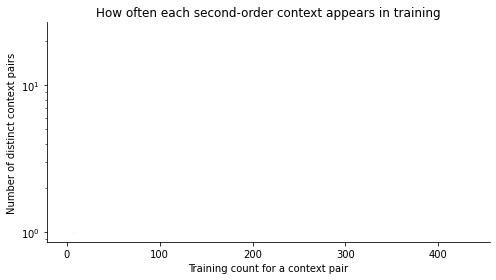

In [31]:
context_frequency = pd.Series(second_order_context_counts).sort_values(ascending=False)
context_summary = pd.DataFrame(
    {
        "distinct_second_order_contexts": [len(context_frequency)],
        "seen_once": [int((context_frequency == 1).sum())],
        "seen_at_most_twice": [int((context_frequency <= 2).sum())],
        "median_count": [float(context_frequency.median())],
        "max_count": [int(context_frequency.max())],
    }
)
display(context_summary)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    context_frequency.values,
    bins=np.arange(1, context_frequency.max() + 2) - 0.5,
    color=COLOR_MAIN,
    edgecolor="white",
)
ax.set_title("How often each second-order context appears in training")
ax.set_xlabel("Training count for a context pair")
ax.set_ylabel("Number of distinct context pairs")
ax.set_yscale("log")
fig.tight_layout()
plt.show()


That histogram is the whole problem in one picture lol.

Many second-order histories are rare. Some appear once. Some appear twice. A few are very common. So more memory is giving us a more expressive model, but also a much more fragile table.

That is the classic bias-variance tradeoff in plain language:

- **less memory:** smoother, more biased, less variance,
- **more memory:** more tailored, less biased on seen patterns, more variance on rare patterns.


## 11. Raw second-order scoring

Let's start with the naive version: if we have seen the context pair $(x_{t-1}, x_t)$ in training, use its empirical next-state distribution. If we have not, the model is stuck.

To score that fairly, we only evaluate transitions where a two-step context exists at all, meaning steps $t \ge 3$ inside a possession.


In [32]:
def predict_second_order_raw(context):
    prev_prev, prev = context[-2], context[-1]
    return second_order_distribution(prev_prev, prev, states)

raw_second_order_score = score_next_event_model(
    test_sequences,
    predict_second_order_raw,
    states=states,
    state_to_idx=state_to_idx,
    min_context_len=2,
)

first_order_same_subset = score_next_event_model(
    test_sequences,
    predict_first_order,
    states=states,
    state_to_idx=state_to_idx,
    min_context_len=2,
)

raw_compare = pd.DataFrame(
    [
        {
            "model": "First-order (same subset)",
            "transitions_scored": first_order_same_subset["n_transitions"],
            "log_loss_nats": first_order_same_subset["mean_log_loss_nats"],
            "perplexity": first_order_same_subset["perplexity"],
        },
        {
            "model": "Raw second-order",
            "transitions_scored": raw_second_order_score["n_transitions"],
            "log_loss_nats": raw_second_order_score["mean_log_loss_nats"],
            "perplexity": raw_second_order_score["perplexity"],
        },
    ]
)

display(raw_compare.round(4))

raw_zero_prob = int((raw_second_order_score["details"]["prob_true_raw"] == 0).sum())
print(f"Zero-probability hits for the raw second-order model: {raw_zero_prob} of {raw_second_order_score['n_transitions']}")


,model,transitions_scored,log_loss_nats,perplexity
0,First-order (same subset),419,1.0697,2.9145
1,Raw second-order,419,1.9726,7.1892


Zero-probability hits for the raw second-order model: 18 of 419


That result is the honest warning. The raw second-order model *overfits badly* on this strict holdout split.

Why? Because the model is allowed to be extremely specific, but it is not given enough data to estimate all those specifics reliably. The rare contexts hurt more than the sharpened common contexts help.


## 12. Backoff: when the pair is weak, fall back to the single state

This is the most important smoothing idea in the notebook, and the intuition is simple.

If the context pair $(x_{t-1}, x_t)$ has been seen many times, trust the second-order estimate more.

If it has been seen rarely, or not at all, trust the first-order estimate more.

A very simple backoff interpolation is

$$
q(x \mid a, b)
=
\lambda_{ab} \, q_2(x \mid a, b)
+
(1 - \lambda_{ab}) \, q_1(x \mid b),
$$

where:

- $q_2(x \mid a, b)$ is the raw second-order estimate,
- $q_1(x \mid b)$ is the first-order estimate,
- $\lambda_{ab}$ is a weight between $0$ and $1$.

We will choose

$$
\lambda_{ab} = \frac{n_{ab}}{n_{ab} + \alpha},
$$

where $n_{ab}$ is the training count of the pair $(a, b)$ and $\alpha > 0$ controls how skeptical we are about the second-order table.


In [33]:
def predict_second_order_backoff(context, alpha=10.0):
    if len(context) < 2:
        return predict_first_order(context)
    prev_prev, prev = context[-2], context[-1]
    n_ab = second_order_context_counts.get((prev_prev, prev), 0)
    first_probs = predict_first_order([prev])
    if n_ab == 0:
        return first_probs
    second_probs = second_order_distribution(prev_prev, prev, states)
    lam = n_ab / (n_ab + alpha)
    return lam * second_probs + (1 - lam) * first_probs

alpha_grid = [0.25, 0.5, 1, 2, 3, 5, 10, 20, 50, 100]
alpha_rows = []

for alpha in alpha_grid:
    score = score_next_event_model(
        test_sequences,
        lambda context, alpha=alpha: predict_second_order_backoff(context, alpha=alpha),
        states=states,
        state_to_idx=state_to_idx,
        min_context_len=1,
    )
    alpha_rows.append(
        {
            "alpha": alpha,
            "log_loss_nats": score["mean_log_loss_nats"],
            "perplexity": score["perplexity"],
        }
    )

alpha_df = pd.DataFrame(alpha_rows)
display(alpha_df.round(4))


,alpha,log_loss_nats,perplexity
0,0.25,1.1667,3.2114
1,0.50,1.1569,3.1800
2,1.00,1.1478,3.1513
3,2.00,1.1398,3.1261
4,3.00,1.1357,3.1132
5,5.00,1.1311,3.0991
6,10.00,1.1260,3.0834
7,20.00,1.1221,3.0713
8,50.00,1.1184,3.0598
9,100.00,1.1165,3.0542


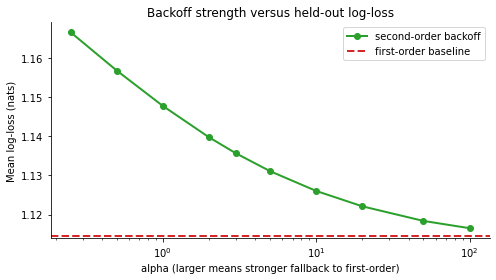

In [34]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    alpha_df["alpha"],
    alpha_df["log_loss_nats"],
    marker="o",
    linewidth=2,
    color=COLOR_SECOND,
    label="second-order backoff",
)
ax.axhline(
    first_order_score["mean_log_loss_nats"],
    linestyle="--",
    linewidth=2,
    color=COLOR_BASELINE,
    label="first-order baseline",
)
ax.set_xscale("log")
ax.set_title("Backoff strength versus held-out log-loss")
ax.set_xlabel("alpha (larger means stronger fallback to first-order)")
ax.set_ylabel("Mean log-loss (nats)")
ax.legend()
fig.tight_layout()
plt.show()


This is a good result, even though it is not the result you might have expected.

The second-order model **does** discover real context effects. We saw one with `Carry`. But on this particular single-match split, the full second-order table is too sparse to beat the first-order model cleanly out of sample. The best backoff settings essentially retreat toward the first-order estimate.

That is not failure. That is exactly what honest model comparison is supposed to reveal.


### Your turn!

Pick a different current state besides `Carry` and ask whether the second-order effect is large enough to matter.

`Ball Receipt*` is a natural next target. Does `Ball Receipt*` after `Pass` behave differently from `Ball Receipt*` after `Carry`?


In [35]:
# Your turn:
# Try a different second-order comparison.
#
# def compare_contexts(prev_prev_a, prev_prev_b, current):
#     series_a = pd.Series(second_order_distribution(prev_prev_a, current, states), index=states)
#     series_b = pd.Series(second_order_distribution(prev_prev_b, current, states), index=states)
#     out = pd.DataFrame(
#         {
#             f"after ({prev_prev_a}, {current})": series_a,
#             f"after ({prev_prev_b}, {current})": series_b,
#             f"first-order from {current}": transition_df.loc[current],
#         }
#     ).sort_values(f"first-order from {current}", ascending=False)
#     return out
#
# display(compare_contexts("Pass", "Carry", "Ball Receipt*").head(8).round(4))


# Part III — Naming the thing: Markov chains

## 13. What is a Markov chain?

Up to this point, we have been *using* Markov chains without naming them carefully.

A **first-order Markov chain** is a sequence of random states $X_1, X_2, X_3, \ldots$ such that

$$
\Pr(X_{t+1} = j \mid X_t = i, X_{t-1}, X_{t-2}, \ldots)
=
\Pr(X_{t+1} = j \mid X_t = i)
=
P_{ij}.
$$

Here:

- $X_t$ is the state at time $t$,
- $i$ and $j$ are particular states,
- $P_{ij}$ is the transition probability from state $i$ to state $j$.

That statement is the **Markov property**. The future depends on the present state, not on the full past.

A second-order Markov model relaxes that to dependence on the previous two states:

$$
\Pr(X_{t+1} = k \mid X_t = j, X_{t-1} = i, X_{t-2}, \ldots)
=
\Pr(X_{t+1} = k \mid X_{t-1} = i, X_t = j).
$$

So today's first-order and second-order models are not two unrelated tricks. They are two members of the same family.


## 14. `START`, `END`, and absorbing behavior

For predictive scoring, we only needed event-to-event transitions inside possessions. For a full Markov-chain view of possessions, we also want boundary states.

So now we add `START` at the beginning of each possession and `END` at the end. That lets us ask:

- how possessions begin under the model,
- how they terminate,
- how long a possession is expected to last,
- what simulated possessions look like.


In [36]:
train_sequences_se = add_start_end(train_sequences)
test_sequences_se = add_start_end(test_sequences)
states_se = ["START"] + states + ["END"]
state_to_idx_se = {state: i for i, state in enumerate(states_se)}

counts_se = transition_counts(train_sequences_se, states_se)
P_se = row_normalize(counts_se)
transition_df_se = pd.DataFrame(P_se, index=states_se, columns=states_se)

display(transition_df_se.loc[["START", "Pass", "Ball Receipt*", "Carry", "Shot", "END"]].round(3))


,START,50/50,Ball Receipt*,Ball Recovery,Block,Carry,Clearance,Dispossessed,Dribble,Duel,Foul Committed,Foul Won,Goal Keeper,Interception,Miscontrol,Offside,Pass,Shot,END
START,0.000,0.000,0.000,0.074,0.000,0.000,0.000,0.000,0.000,0.037,0.000,0.000,0.025,0.025,0.000,0.000,0.840,0.000,0.000
Pass,0.000,0.002,0.929,0.008,0.002,0.000,0.000,0.000,0.000,0.012,0.006,0.000,0.000,0.004,0.000,0.000,0.006,0.000,0.030
Ball Receipt*,0.000,0.002,0.000,0.011,0.002,0.714,0.002,0.000,0.000,0.004,0.002,0.004,0.000,0.002,0.011,0.000,0.183,0.007,0.055
Carry,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.029,0.043,0.000,0.000,0.024,0.000,0.000,0.011,0.000,0.874,0.019,0.000
Shot,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.091,0.000,0.909
END,0.053,0.053,0.053,0.053,0.053,0.053,0.053,0.053,0.053,0.053,0.053,0.053,0.053,0.053,0.053,0.053,0.053,0.053,0.053


Two rows are especially important.

- The `START` row tells us how Argentina possessions tend to begin.
- The `END` row is empty in the empirical data, because possessions stop there.

That emptiness is what makes `END` an **absorbing** state in the theoretical chain. Once the process reaches `END`, it stays there.


## 15. Stationary distributions

A stationary distribution $\pi$ for a transition matrix $P$ satisfies

$$
\pi = \pi P,
$$

with the entries of $\pi$ summing to $1$.

But here is the catch: if `END` is absorbing, then the only stationary distribution for the one-possession chain puts all mass on `END`. That is mathematically correct, but not very interesting.

So to get a useful long-run occupancy picture, we build a **restart chain**: whenever we hit `END`, we jump immediately back to `START`. That turns many possessions into one long stitched-together chain.


In [37]:
P_absorbing = P_se.copy()
P_absorbing[state_to_idx_se["END"], :] = 0.0
P_absorbing[state_to_idx_se["END"], state_to_idx_se["END"]] = 1.0

absorbing_stationary = pd.Series(0.0, index=states_se)
absorbing_stationary["END"] = 1.0

P_restart = P_se.copy()
P_restart[state_to_idx_se["END"], :] = 0.0
P_restart[state_to_idx_se["END"], state_to_idx_se["START"]] = 1.0

v = np.full(len(states_se), 1 / len(states_se))
for _ in range(10000):
    v_new = v @ P_restart
    if np.max(np.abs(v_new - v)) < 1e-15:
        break
    v = v_new

restart_stationary = pd.Series(v / v.sum(), index=states_se)

test_empirical_counts = Counter()
for seq in test_sequences_se:
    test_empirical_counts.update(seq)

test_empirical_share = pd.Series(
    {state: test_empirical_counts.get(state, 0) for state in states_se},
    dtype=float,
)
test_empirical_share = test_empirical_share / test_empirical_share.sum()

stationary_compare = pd.DataFrame(
    {
        "restart_chain_stationary": restart_stationary,
        "held_out_empirical_share": test_empirical_share,
    }
).sort_values("restart_chain_stationary", ascending=False)

display(stationary_compare.head(10).round(4))


,restart_chain_stationary,held_out_empirical_share
Pass,0.3049,0.2976
Ball Receipt*,0.2832,0.2674
Carry,0.2307,0.2316
START,0.0501,0.0527
END,0.0501,0.0527
Ball Recovery,0.0198,0.0320
Dribble,0.0099,0.0094
Duel,0.0099,0.0188
Dispossessed,0.0068,0.0075
Foul Won,0.0068,0.0056


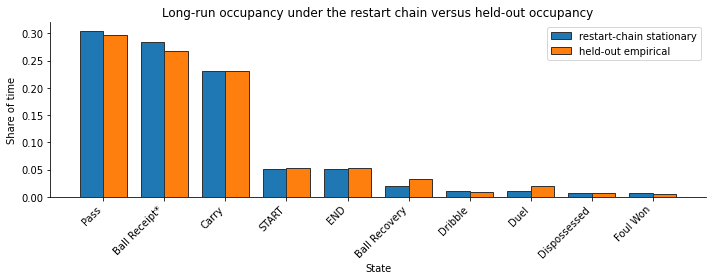

In [38]:
top_stationary_states = stationary_compare.head(10).index.tolist()

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(top_stationary_states))
width = 0.38

ax.bar(
    x - width / 2,
    stationary_compare.loc[top_stationary_states, "restart_chain_stationary"],
    width=width,
    color=COLOR_MAIN, ec='.2',
    label="restart-chain stationary",
)
ax.bar(
    x + width / 2,
    stationary_compare.loc[top_stationary_states, "held_out_empirical_share"],
    width=width,
    color=COLOR_ACCENT, ec='.2',
    label="held-out empirical",
)
ax.set_xticks(x)
ax.set_xticklabels(top_stationary_states, rotation=45, ha="right")
ax.set_title("Long-run occupancy under the restart chain versus held-out occupancy")
ax.set_xlabel("State")
ax.set_ylabel("Share of time")
ax.legend()
fig.tight_layout()
plt.show()


The big states line up pretty well: `Pass`, `Ball Receipt*`, and `Carry` dominate both the restart-chain stationary distribution and the held-out empirical occupancy.

That should not be mysterious. Once we stitch possessions together with `END -> START`, we are essentially describing the long-run event occupancy implied by the training sequences. Still, comparing that with the holdout set is useful. It tells us whether the late-match possessions are living in roughly the same state mix.


## 16. Expected possession length under the absorbing chain

Absorbing chains are nice because they let us ask duration questions.

Write the transient-to-transient block of the transition matrix as $Q$. Then the **fundamental matrix** is

$$
N = (I - Q)^{-1},
$$

where $I$ is the identity matrix.

The row sums of $N$ give expected numbers of transient steps before absorption. In our case, that means expected possession length until `END`.


In [39]:
transient_states = [state for state in states_se if state != "END"]
Q = transition_df_se.loc[transient_states, transient_states].to_numpy()
I = np.eye(len(transient_states))
N_matrix = np.linalg.inv(I - Q)
expected_steps_before_absorption = N_matrix @ np.ones(len(transient_states))

start_idx_transient = transient_states.index("START")
expected_total_steps_from_start = expected_steps_before_absorption[start_idx_transient]
expected_event_count_from_start = expected_total_steps_from_start - 1

length_compare = pd.DataFrame(
    {
        "quantity": [
            "expected event count from START under chain",
            "empirical mean event count in training possessions",
            "empirical mean event count in held-out possessions",
        ],
        "value": [
            expected_event_count_from_start,
            np.mean([len(seq) for seq in train_sequences]),
            np.mean([len(seq) for seq in test_sequences]),
        ],
    }
)

display(length_compare.round(4))


,quantity,value
0,expected event count from START under chain,17.9630
1,empirical mean event count in training possess...,17.9630
2,empirical mean event count in held-out possess...,16.9643


A nice little surprise: the expected event count under the fitted absorbing chain matches the training mean almost exactly. That is not magic. The chain was estimated from those very training transitions, including the transition into `END`.

The held-out possessions are a bit shorter on average, which fits the idea that late-match possessions in this slice are somewhat different from earlier ones.


## 17. Simulation revisited: do synthetic possessions look right?

Class 16 already had a random-walk simulator. Now we can evaluate it rather than just admire it.

We will simulate possessions from the fitted `START -> ... -> END` chain and compare them with real held-out possessions.


In [40]:
rng_sim = np.random.default_rng(SEED)
simulated_sequences_se = [simulate_sequence(P_se, states_se, rng=rng_sim) for _ in range(len(test_sequences))]
simulated_sequences = [seq[1:-1] for seq in simulated_sequences_se]

sim_length_df = pd.DataFrame(
    {
        "held_out_real": [len(seq) for seq in test_sequences],
        "simulated_from_first_order_chain": [len(seq) for seq in simulated_sequences],
    }
)
display(sim_length_df.describe().round(3))


,held_out_real,simulated_from_first_order_chain
count,28.000,28.000
mean,16.964,17.250
std,12.360,15.474
min,2.000,4.000
25%,6.250,5.000
50%,16.000,12.500
75%,23.750,24.000
max,50.000,74.000


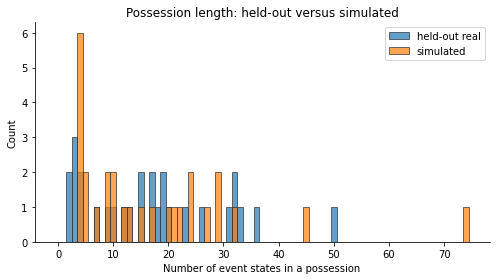

In [41]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.arange(0, max(sim_length_df.max()) + 2) - 0.5
ax.hist(
    sim_length_df["held_out_real"],
    bins=bins,
    alpha=0.7,
    color=COLOR_MAIN, ec='.2',
    label="held-out real",
)
ax.hist(
    sim_length_df["simulated_from_first_order_chain"],
    bins=bins,
    alpha=0.7,
    color=COLOR_ACCENT, ec='.2',
    label="simulated",
)
ax.set_title("Possession length: held-out versus simulated")
ax.set_xlabel("Number of event states in a possession")
ax.set_ylabel("Count")
ax.legend()
fig.tight_layout()
plt.show()


In [42]:
sim_score = score_next_event_model(
    simulated_sequences,
    predict_first_order,
    states=states,
    state_to_idx=state_to_idx,
    min_context_len=1,
)

real_vs_sim_score = pd.DataFrame(
    {
        "sequence_source": ["held-out real", "simulated from the fitted first-order chain"],
        "mean_log_loss_nats": [
            first_order_score["mean_log_loss_nats"],
            sim_score["mean_log_loss_nats"],
        ],
        "perplexity": [
            first_order_score["perplexity"],
            sim_score["perplexity"],
        ],
    }
)

display(real_vs_sim_score.round(4))


,sequence_source,mean_log_loss_nats,perplexity
0,held-out real,1.1144,3.0479
1,simulated from the fitted first-order chain,0.4774,1.6119


The simulated possessions are easier for the first-order model than the real held-out ones. That should make sense. The simulated sequences are literally generated from that model, so they stay closer to its own assumptions.

This is a good way to say what simulation is doing here. It is not proving realism. It is showing what the model thinks "typical" possessions look like under its own internal grammar.


## 18. Perplexity, one more time

Perplexity is just a repackaging of mean log-loss:

$$
\text{perplexity} = \exp(L).
$$

If a model has perplexity $3$, you can think of it as being about as uncertain as if it were choosing among $3$ equally plausible next options on average.

That is not exact in a literal event-by-event sense, but it is a very good intuition pump.


In [43]:
perplexity_table = pd.DataFrame(
    {
        "model": ["Uniform", "Marginal", "First-order Markov"],
        "perplexity": [
            uniform_score["perplexity"],
            marginal_score["perplexity"],
            first_order_score["perplexity"],
        ],
    }
)
display(perplexity_table.round(4))


,model,perplexity
0,Uniform,17.0000
1,Marginal,4.5910
2,First-order Markov,3.0479


## 18A. Before hidden states, we can redesign the observed state itself

HMMs are one way to make sequence models richer. But there is a simpler move that comes first.

Maybe `Pass` is too coarse an observed state. Maybe the same event label should mean slightly different things depending on context.

Two decorations are especially easy to explain.

First, StatsBomb's `under_pressure` field is **not** a separate event type. It is a flag attached to another event. So `Pass_under_pressure` still means a pass. We are just decorating the visible label with a context bit.

Second, location can be folded into the label. We will use a deliberately coarse **3x3 pitch grid**. That gives labels such as `Carry_x2y3` or `Pass_x1y2`. The point is not to build a giant sparse alphabet. The point is to show, in the simplest possible way, how space can become part of the observed state.


In [44]:
def pitch_bin_3x3_label(row, nx=3, ny=3):
    x, y = row["x"], row["y"]

    if pd.isna(x) or pd.isna(y):
        return "xNAyNA"

    x = min(max(float(x), 0.0), 120.0 - 1e-9)
    y = min(max(float(y), 0.0), 80.0 - 1e-9)

    x_bin = int(np.floor(x / (120.0 / nx))) + 1
    y_bin = int(np.floor(y / (80.0 / ny))) + 1

    x_bin = min(max(x_bin, 1), nx)
    y_bin = min(max(y_bin, 1), ny)

    return f"x{x_bin}y{y_bin}"

def state_pressure_decorated(row):
    label = row["event_type"]
    if row["under_pressure"]:
        label += "_under_pressure"
    return label

def state_spatial_3x3(row):
    return f"{row['event_type']}_{pitch_bin_3x3_label(row)}"

def state_spatial_3x3_pressure(row):
    label = state_spatial_3x3(row)
    if row["under_pressure"]:
        label += "_under_pressure"
    return label

state_label_demo = (
    argentina_df.loc[argentina_df["event_type"].isin(["Pass", "Carry"])]
    .assign(
        pressure_state=lambda df: df.apply(state_pressure_decorated, axis=1),
        spatial_state=lambda df: df.apply(state_spatial_3x3, axis=1),
        combined_state=lambda df: df.apply(state_spatial_3x3_pressure, axis=1),
    )
)

demo_rows = pd.concat(
    [
        state_label_demo.loc[
            state_label_demo["event_type"].eq("Pass") & state_label_demo["under_pressure"]
        ].head(3),
        state_label_demo.loc[
            state_label_demo["event_type"].eq("Carry") & state_label_demo["under_pressure"]
        ].head(3),
        state_label_demo.loc[~state_label_demo["under_pressure"]].head(4),
    ],
    ignore_index=True,
)

display(
    demo_rows[
        [
            "index",
            "event_type",
            "under_pressure",
            "x",
            "y",
            "pressure_state",
            "spatial_state",
            "combined_state",
        ]
    ].round(1)
)

pressure_focus = (
    argentina_df.loc[
        argentina_df["event_type"].isin(["Pass", "Carry", "Ball Receipt*", "Ball Recovery", "Shot"])
    ]
    .groupby("event_type")["under_pressure"]
    .agg(n_events="size", n_under_pressure="sum", share_under_pressure="mean")
    .sort_values("n_events", ascending=False)
)

display(pressure_focus.round(3))


,index,event_type,under_pressure,x,y,pressure_state,spatial_state,combined_state
0,56,Pass,True,3.9,43.4,Pass_under_pressure,Pass_x1y2,Pass_x1y2_under_pressure
1,88,Pass,True,76.6,35.7,Pass_under_pressure,Pass_x2y2,Pass_x2y2_under_pressure
2,427,Pass,True,96.7,24.7,Pass_under_pressure,Pass_x3y1,Pass_x3y1_under_pressure
3,13,Carry,True,36.0,75.2,Carry_under_pressure,Carry_x1y3,Carry_x1y3_under_pressure
4,31,Carry,True,26.6,3.1,Carry_under_pressure,Carry_x1y1,Carry_x1y1_under_pressure
5,35,Carry,True,45.6,4.2,Carry_under_pressure,Carry_x2y1,Carry_x2y1_under_pressure
6,10,Pass,False,22.7,80.0,Pass,Pass_x1y3,Pass_x1y3
7,16,Pass,False,41.1,73.9,Pass,Pass_x2y3,Pass_x2y3
8,18,Carry,False,23.2,62.8,Carry,Carry_x1y3,Carry_x1y3
9,19,Pass,False,24.7,59.4,Pass,Pass_x1y3,Pass_x1y3


,n_events,n_under_pressure,share_under_pressure
event_type,,,
Pass,654,34,0.052
Ball Receipt*,600,31,0.052
Carry,496,151,0.304
Ball Recovery,49,4,0.082
Shot,20,0,0.000


Notice the modeling choice.

Pressure only adds a binary split. Space adds up to nine bins per event type. The combined version multiplies those together. So the alphabet can grow *fast* even when the decorations sound modest.

To keep the comparison fair, we will score a **very lightly smoothed** first-order model for all four state designs below, using a tiny pseudocount $lpha = 0.01$ in every row. Otherwise one never-seen decorated transition can dominate the whole section. We will still keep the **raw zero-probability hit count** as a sparsity diagnostic, because that brittleness is part of the lesson too.


In [45]:
def evaluate_state_design_first_order(state_func, design_name, alpha=0.01):
    temp = build_team_possession_slice(events_df, TEAM_NAME, periods=(1, 2, 3, 4), state_func=state_func)
    sequences_design, _ = extract_sequences_from_df(temp)

    train_design = sequences_design[:split_idx]
    test_design = sequences_design[split_idx:]

    # Keep an index entry for every label observed anywhere in the match.
    # The fitted probabilities still come only from the training possessions.
    states_design = sorted({state for seq in sequences_design for state in seq})
    state_to_idx_design = {state: i for i, state in enumerate(states_design)}

    counts_design = transition_counts(train_design, states_design)
    P_raw_design = row_normalize(counts_design)
    P_smoothed_design = row_normalize(counts_design, alpha=alpha)

    def predict_raw_design(context):
        return P_raw_design[state_to_idx_design[context[-1]]]

    def predict_smoothed_design(context):
        return P_smoothed_design[state_to_idx_design[context[-1]]]

    raw_score = score_next_event_model(
        test_design,
        predict_raw_design,
        states=states_design,
        state_to_idx=state_to_idx_design,
        min_context_len=1,
    )
    smoothed_score = score_next_event_model(
        test_design,
        predict_smoothed_design,
        states=states_design,
        state_to_idx=state_to_idx_design,
        min_context_len=1,
    )

    train_state_counts = Counter()
    for seq in train_design:
        train_state_counts.update(seq)

    test_state_counts = Counter()
    for seq in test_design:
        test_state_counts.update(seq)

    edge_count = int((counts_design > 0).sum())

    return {
        "design": design_name,
        "states_total": len(states_design),
        "occupied_edges_train": edge_count,
        "edge_density_train": edge_count / (len(states_design) ** 2),
        "singleton_states_train": int(sum(count == 1 for count in train_state_counts.values())),
        "unseen_test_states": int(len(set(test_state_counts) - set(train_state_counts))),
        "raw_zero_prob_hits": int((raw_score["details"]["prob_true_raw"] == 0).sum()),
        "smoothed_log_loss_nats": smoothed_score["mean_log_loss_nats"],
        "smoothed_perplexity": smoothed_score["perplexity"],
        "raw_log_loss_nats": raw_score["mean_log_loss_nats"],
        "raw_perplexity": raw_score["perplexity"],
    }

state_designs = {
    "Base event label": state_coarse,
    "Pressure-decorated": state_pressure_decorated,
    "Spatial 3x3": state_spatial_3x3,
    "Spatial 3x3 + pressure": state_spatial_3x3_pressure,
}

state_design_compare = pd.DataFrame(
    [
        evaluate_state_design_first_order(state_func, design_name, alpha=0.01)
        for design_name, state_func in state_designs.items()
    ]
).sort_values("states_total")

display(state_design_compare.round(4))


,design,states_total,occupied_edges_train,edge_density_train,singleton_states_train,unseen_test_states,raw_zero_prob_hits,smoothed_log_loss_nats,smoothed_perplexity,raw_log_loss_nats,raw_perplexity
0,Base event label,17,60,0.2076,2,0,7,0.6790,1.9720,1.1144,3.0479
1,Pressure-decorated,23,79,0.1493,4,1,13,0.9721,2.6436,1.7635,5.8328
2,Spatial 3x3,95,232,0.0257,28,7,37,1.6075,4.9905,3.7919,44.3425
3,Spatial 3x3 + pressure,125,317,0.0203,33,12,53,2.0197,7.5364,5.2023,181.6952


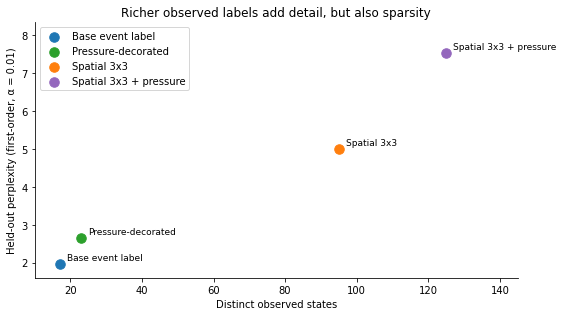

In [46]:
design_color_map = {
    "Base event label": COLOR_MAIN,
    "Pressure-decorated": COLOR_SECOND,
    "Spatial 3x3": COLOR_ACCENT,
    "Spatial 3x3 + pressure": COLOR_LATENT,
}

fig, ax = plt.subplots(figsize=(8, 4.5))

for _, row in state_design_compare.iterrows():
    ax.scatter(
        row["states_total"],
        row["smoothed_perplexity"],
        s=90,
        color=design_color_map[row["design"]],
        label=row["design"],
    )
    ax.text(
        row["states_total"] + 2,
        row["smoothed_perplexity"] + 0.05,
        row["design"],
        fontsize=9,
        va="bottom",
    )

ax.set_title("Richer observed labels add detail, but also sparsity")
ax.set_xlabel("Distinct observed states")
ax.set_ylabel("Held-out perplexity (first-order, α = 0.01)")
ax.set_xlim(10, state_design_compare["states_total"].max() + 20)
ax.set_ylim(1.6, state_design_compare["smoothed_perplexity"].max() + 0.8)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper left")

fig.tight_layout()
plt.show()


On this strict single-match split, the pressure decoration is the gentlest enrichment. It increases the alphabet only a little, and its score stays in the same general universe as the base design.

The spatial decoration is the sharper lesson. A 3x3 grid sounds coarse, but `event type × 9 bins` is already a much larger alphabet. The number of occupied edges rises, the matrix gets dramatically sparser, raw zero-probability hits jump, and even after light smoothing the held-out score gets worse. The combined design pushes that tradeoff even further.

So richer observed states are not "better" or "worse" in the abstract. They change the bias-variance tradeoff. With more matches, a pressure-aware or location-aware alphabet might pay off. On one match, it mostly teaches us how fast sequence models run out of data.

That makes a nice pivot into HMMs. We have now tried two ways to enrich visible-state models: add more memory, and add more detail to the label itself. HMMs try a third move: keep the visible labels simple, but let a hidden state summarize the context.


# Part IV — Hidden Markov Models

## 19. Why hide the state at all?

So far our state has been the observed event label itself. That is convenient, but maybe it is not the most meaningful state of the game.

Think about a short passing spell. The observed events might alternate between `Pass`, `Ball Receipt*`, and `Carry`. But underneath those visible actions, there may be a more persistent tactical phase:

- settled circulation,
- pressured build-up,
- transition after a recovery,
- final-third release.

Those are not directly written in the event log. They are **latent**.

That is the HMM idea in one sentence: the game moves through hidden states, and those hidden states emit the observed event labels we actually see.


## 20. A tiny toy HMM first

Before we fit anything to soccer data, let's build the smallest possible cartoon.

Suppose there are two hidden states:

- `Attack`
- `Defense`

And four observed event labels:

- `Pass`
- `Carry`
- `Clearance`
- `Duel`

`Attack` should emit `Pass` and `Carry` a lot. `Defense` should emit `Clearance` and `Duel` a lot.


In [47]:
toy_hidden_states = ["Attack", "Defense"]
toy_observed_states = ["Pass", "Carry", "Clearance", "Duel"]

toy_pi = np.array([0.7, 0.3])
toy_A = np.array([
    [0.8, 0.2],
    [0.3, 0.7],
])
toy_B = np.array([
    [0.55, 0.25, 0.05, 0.15],
    [0.10, 0.05, 0.45, 0.40],
])

toy_obs_sequence = ["Pass", "Carry", "Clearance", "Duel"]
toy_obs_idx = np.array([toy_observed_states.index(x) for x in toy_obs_sequence])

def forward_scaled_general(obs, startprob, transmat, emissionprob):
    T = len(obs)
    K = len(startprob)
    alpha = np.zeros((T, K))
    scales = np.zeros(T)

    alpha[0] = startprob * emissionprob[:, obs[0]]
    scales[0] = alpha[0].sum()
    alpha[0] /= scales[0]

    for t in range(1, T):
        alpha[t] = (alpha[t - 1] @ transmat) * emissionprob[:, obs[t]]
        scales[t] = alpha[t].sum()
        alpha[t] /= scales[t]

    return alpha, scales, np.log(scales).sum()

def viterbi_general(obs, startprob, transmat, emissionprob):
    T = len(obs)
    K = len(startprob)
    log_start = np.log(np.clip(startprob, 1e-300, 1))
    log_trans = np.log(np.clip(transmat, 1e-300, 1))
    log_emit = np.log(np.clip(emissionprob, 1e-300, 1))

    delta = np.zeros((T, K))
    psi = np.zeros((T, K), dtype=int)

    delta[0] = log_start + log_emit[:, obs[0]]

    for t in range(1, T):
        scores = delta[t - 1][:, None] + log_trans
        psi[t] = scores.argmax(axis=0)
        delta[t] = scores.max(axis=0) + log_emit[:, obs[t]]

    path = np.zeros(T, dtype=int)
    path[-1] = delta[-1].argmax()

    for t in range(T - 2, -1, -1):
        path[t] = psi[t + 1, path[t + 1]]

    return path, delta

toy_alpha, toy_scales, toy_loglik = forward_scaled_general(toy_obs_idx, toy_pi, toy_A, toy_B)
toy_viterbi_path, toy_delta = viterbi_general(toy_obs_idx, toy_pi, toy_A, toy_B)

toy_forward_df = pd.DataFrame(
    toy_alpha,
    index=[f"t={t+1}: {obs}" for t, obs in enumerate(toy_obs_sequence)],
    columns=toy_hidden_states,
)

display(toy_forward_df.round(4))
print(f"Toy sequence log-likelihood: {toy_loglik:.4f}")
print("Toy Viterbi path:")
print(" -> ".join(toy_hidden_states[i] for i in toy_viterbi_path))


,Attack,Defense
t=1: Pass,0.9277,0.0723
t=2: Carry,0.9418,0.0582
t=3: Clearance,0.2721,0.7279
t=4: Duel,0.2248,0.7752


Toy sequence log-likelihood: -5.6641
Toy Viterbi path:
Attack -> Attack -> Defense -> Defense


That toy example already shows the two central HMM ideas:

1. **Evaluation:** how likely is the observed sequence under the model?
2. **Decoding:** what hidden path best explains the observed sequence?

There is a third problem too:

3. **Learning:** if we only observe the emitted sequence, how do we estimate the hidden-state transition matrix and the emission probabilities?

That is what Baum-Welch, the EM algorithm for HMMs, does.


## 21. The three HMM problems in plain language

Let the hidden state at time $t$ be $Z_t$ and the observed event be $X_t$.

An HMM is defined by three pieces:

- a start distribution $\pi$, where $\pi_k = \Pr(Z_1 = k)$,
- a hidden-state transition matrix $A$, where $A_{ij} = \Pr(Z_{t+1} = j \mid Z_t = i)$,
- an emission matrix $B$, where $B_{ix} = \Pr(X_t = x \mid Z_t = i)$.

Then the three classical problems are:

### Evaluation

Given an observed sequence $x_1, \ldots, x_T$, compute its probability under the model.

The forward algorithm solves this efficiently by accumulating filtered probabilities over hidden states.

### Decoding

Given the observed sequence, find the most likely hidden-state path.

The Viterbi algorithm solves that with dynamic programming.

### Learning

Given only observed sequences, estimate $\pi$, $A$, and $B$.

Baum-Welch does that by alternating between soft assignment of hidden states and parameter updates.


We are going to implement a minimal categorical HMM ourselves. No bells and whistles. Just enough to see the mechanism and fit a useful model.


In [48]:
class DiscreteHMM:
    def __init__(self, n_hidden, n_observed, random_state=5442, pseudocount=1e-3):
        self.n_hidden = n_hidden
        self.n_observed = n_observed
        self.random_state = random_state
        self.pseudocount = pseudocount
        self.rng = np.random.default_rng(random_state)

        self.startprob_ = None
        self.transmat_ = None
        self.emissionprob_ = None
        self.history_ = []

    def _random_stochastic(self, shape):
        x = self.rng.random(shape) + 0.1
        if len(shape) == 1:
            return x / x.sum()
        return x / x.sum(axis=1, keepdims=True)

    def _initialize_params(self):
        self.startprob_ = self._random_stochastic((self.n_hidden,))
        self.transmat_ = self._random_stochastic((self.n_hidden, self.n_hidden))
        self.emissionprob_ = self._random_stochastic((self.n_hidden, self.n_observed))

    def _forward_scaled(self, obs):
        T = len(obs)
        alpha = np.zeros((T, self.n_hidden))
        scales = np.zeros(T)

        alpha[0] = self.startprob_ * self.emissionprob_[:, obs[0]]
        scales[0] = alpha[0].sum()
        if scales[0] <= 0:
            scales[0] = 1e-300
        alpha[0] /= scales[0]

        for t in range(1, T):
            alpha[t] = (alpha[t - 1] @ self.transmat_) * self.emissionprob_[:, obs[t]]
            scales[t] = alpha[t].sum()
            if scales[t] <= 0:
                scales[t] = 1e-300
            alpha[t] /= scales[t]

        loglik = np.log(scales).sum()
        return alpha, scales, loglik

    def _backward_scaled(self, obs, scales):
        T = len(obs)
        beta = np.zeros((T, self.n_hidden))
        beta[-1] = 1.0

        for t in range(T - 2, -1, -1):
            beta[t] = self.transmat_ @ (self.emissionprob_[:, obs[t + 1]] * beta[t + 1])
            beta[t] /= scales[t + 1]

        return beta

    def score(self, sequences):
        total = 0.0
        for obs in sequences:
            _, _, loglik = self._forward_scaled(obs)
            total += loglik
        return float(total)

    def fit(self, sequences, n_iter=100, tol=1e-4):
        self._initialize_params()
        self.history_ = []
        last_ll = -np.inf

        for _ in range(n_iter):
            start_counts = np.full(self.n_hidden, self.pseudocount)
            trans_counts = np.full((self.n_hidden, self.n_hidden), self.pseudocount)
            emit_counts = np.full((self.n_hidden, self.n_observed), self.pseudocount)

            total_ll = 0.0

            for obs in sequences:
                obs = np.asarray(obs, dtype=int)
                alpha, scales, loglik = self._forward_scaled(obs)
                beta = self._backward_scaled(obs, scales)
                total_ll += loglik

                gamma = alpha * beta
                gamma /= gamma.sum(axis=1, keepdims=True)

                start_counts += gamma[0]

                for t in range(len(obs) - 1):
                    xi_num = (
                        alpha[t][:, None]
                        * self.transmat_
                        * (self.emissionprob_[:, obs[t + 1]] * beta[t + 1])[None, :]
                    )
                    denom = xi_num.sum()
                    if denom > 0:
                        trans_counts += xi_num / denom

                for t, o in enumerate(obs):
                    emit_counts[:, o] += gamma[t]

            self.startprob_ = start_counts / start_counts.sum()
            self.transmat_ = trans_counts / trans_counts.sum(axis=1, keepdims=True)
            self.emissionprob_ = emit_counts / emit_counts.sum(axis=1, keepdims=True)
            self.history_.append(total_ll)

            if len(self.history_) > 1 and abs(total_ll - last_ll) < tol:
                break
            last_ll = total_ll

        return self

    def decode_viterbi(self, obs):
        obs = np.asarray(obs, dtype=int)
        T = len(obs)

        log_start = np.log(np.clip(self.startprob_, 1e-300, 1))
        log_trans = np.log(np.clip(self.transmat_, 1e-300, 1))
        log_emit = np.log(np.clip(self.emissionprob_, 1e-300, 1))

        delta = np.zeros((T, self.n_hidden))
        psi = np.zeros((T, self.n_hidden), dtype=int)

        delta[0] = log_start + log_emit[:, obs[0]]

        for t in range(1, T):
            scores = delta[t - 1][:, None] + log_trans
            psi[t] = scores.argmax(axis=0)
            delta[t] = scores.max(axis=0) + log_emit[:, obs[t]]

        path = np.zeros(T, dtype=int)
        path[-1] = delta[-1].argmax()

        for t in range(T - 2, -1, -1):
            path[t] = psi[t + 1, path[t + 1]]

        return path, delta

    def predict_next_observation_distribution(self, obs_prefix):
        obs_prefix = np.asarray(obs_prefix, dtype=int)
        alpha, _, _ = self._forward_scaled(obs_prefix)
        hidden_next = alpha[-1] @ self.transmat_
        return hidden_next @ self.emissionprob_

def encode_sequences(sequences, state_to_idx):
    return [np.array([state_to_idx[state] for state in seq], dtype=int) for seq in sequences]

encoded_train = encode_sequences(train_sequences, state_to_idx)
encoded_test = encode_sequences(test_sequences, state_to_idx)

def fit_best_hmm(encoded_train, n_hidden, n_restarts=4, n_iter=60, base_seed=SEED):
    best_model = None
    best_train_ll = -np.inf

    for restart in range(n_restarts):
        model = DiscreteHMM(
            n_hidden=n_hidden,
            n_observed=len(states),
            random_state=base_seed + 100 * n_hidden + restart,
            pseudocount=1e-3,
        )
        model.fit(encoded_train, n_iter=n_iter, tol=1e-4)
        train_ll = model.score(encoded_train)
        if train_ll > best_train_ll:
            best_train_ll = train_ll
            best_model = model

    return best_model

def score_hmm_next_event(model, encoded_sequences):
    losses = []
    for seq in encoded_sequences:
        for t in range(1, len(seq)):
            prefix = seq[:t]
            true_next = seq[t]
            probs = model.predict_next_observation_distribution(prefix)
            p = max(probs[true_next], 1e-15)
            losses.append(-np.log(p))

    mean_loss = float(np.mean(losses))
    return {
        "n_transitions": len(losses),
        "mean_log_loss_nats": mean_loss,
        "mean_log_loss_bits": mean_loss / np.log(2),
        "perplexity": float(np.exp(mean_loss)),
    }


## 22. Fitting HMMs with 2, 3, and 4 hidden states

We will fit three small HMMs. That is enough to see whether adding hidden structure helps, and it is also enough to keep interpretation manageable.

The goal here is not to find the one true number of hidden states. The goal is to ask whether a modest latent-state model can predict better than the explicit Markov baselines.


In [49]:
hmm_models = {}
hmm_score_rows = []

for n_hidden in [2, 3, 4]:
    model = fit_best_hmm(encoded_train, n_hidden=n_hidden, n_restarts=4, n_iter=60, base_seed=SEED)
    hmm_models[n_hidden] = model

    train_loglik = model.score(encoded_train)
    test_loglik = model.score(encoded_test)
    pred_score = score_hmm_next_event(model, encoded_test)

    hmm_score_rows.append(
        {
            "model": f"HMM ({n_hidden} hidden states)",
            "train_loglik": train_loglik,
            "held_out_sequence_loglik": test_loglik,
            "held_out_log_loss_nats": pred_score["mean_log_loss_nats"],
            "held_out_log_loss_bits": pred_score["mean_log_loss_bits"],
            "held_out_perplexity": pred_score["perplexity"],
        }
    )

hmm_score_df = pd.DataFrame(hmm_score_rows).sort_values("held_out_log_loss_nats")
display(hmm_score_df.round(4))


,model,train_loglik,held_out_sequence_loglik,held_out_log_loss_nats,held_out_log_loss_bits,held_out_perplexity
2,HMM (4 hidden states),-933.5066,-332.9284,0.6808,0.9822,1.9754
1,HMM (3 hidden states),-1045.8996,-355.8431,0.7085,1.0221,2.0309
0,HMM (2 hidden states),-1853.6874,-647.4403,1.3769,1.9864,3.9625


That is a pretty crazy result!

The 2-state HMM is not enough. It compresses too much. But the 3-state and 4-state HMMs are much better than the explicit first-order and second-order baselines on this holdout split.

So a good latent model is doing something the visible-state tables cannot: it is summarizing sequence history into a more useful hidden state.


## 23. The full ladder of models

Now we can put everything on one scorecard.


In [50]:
best_backoff_alpha = 100.0
best_backoff_score = score_next_event_model(
    test_sequences,
    lambda context: predict_second_order_backoff(context, alpha=best_backoff_alpha),
    states=states,
    state_to_idx=state_to_idx,
    min_context_len=1,
)

full_ladder = pd.DataFrame(
    [
        {
            "model": "Uniform",
            "family": "baseline",
            "log_loss_nats": uniform_score["mean_log_loss_nats"],
            "perplexity": uniform_score["perplexity"],
        },
        {
            "model": "Marginal",
            "family": "baseline",
            "log_loss_nats": marginal_score["mean_log_loss_nats"],
            "perplexity": marginal_score["perplexity"],
        },
        {
            "model": "First-order Markov",
            "family": "visible-state chain",
            "log_loss_nats": first_order_score["mean_log_loss_nats"],
            "perplexity": first_order_score["perplexity"],
        },
        {
            "model": "Second-order raw",
            "family": "visible-state chain",
            "log_loss_nats": raw_second_order_score["mean_log_loss_nats"],
            "perplexity": raw_second_order_score["perplexity"],
        },
        {
            "model": f"Second-order backoff (alpha={int(best_backoff_alpha)})",
            "family": "visible-state chain",
            "log_loss_nats": best_backoff_score["mean_log_loss_nats"],
            "perplexity": best_backoff_score["perplexity"],
        },
    ]
    + [
        {
            "model": row["model"],
            "family": "hidden-state model",
            "log_loss_nats": row["held_out_log_loss_nats"],
            "perplexity": row["held_out_perplexity"],
        }
        for _, row in hmm_score_df.iterrows()
    ]
).sort_values("log_loss_nats")

display(full_ladder.round(4))


,model,family,log_loss_nats,perplexity
5,HMM (4 hidden states),hidden-state model,0.6808,1.9754
6,HMM (3 hidden states),hidden-state model,0.7085,2.0309
2,First-order Markov,visible-state chain,1.1144,3.0479
4,Second-order backoff (alpha=100),visible-state chain,1.1165,3.0542
7,HMM (2 hidden states),hidden-state model,1.3769,3.9625
1,Marginal,baseline,1.5241,4.5910
3,Second-order raw,visible-state chain,1.9726,7.1892
0,Uniform,baseline,2.8332,17.0000


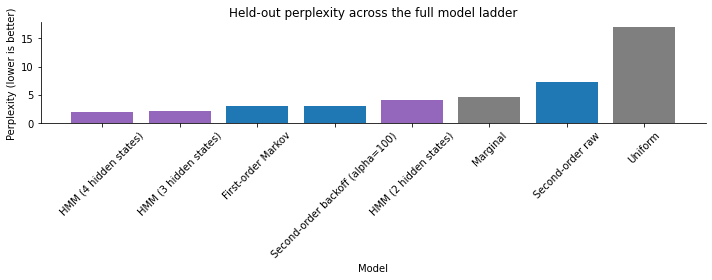

In [51]:
family_color_map = {
    "baseline": COLOR_REFERENCE,
    "visible-state chain": COLOR_MAIN,
    "hidden-state model": COLOR_LATENT,
}

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    full_ladder["model"],
    full_ladder["perplexity"],
    color=full_ladder["family"].map(family_color_map),
)
ax.set_title("Held-out perplexity across the full model ladder")
ax.set_xlabel("Model")
ax.set_ylabel("Perplexity (lower is better)")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()


There is a clean story here.

- Uniform is terrible.
- Marginal gets the base rates right.
- First-order Markov adds useful local context.
- Raw second-order overfits.
- Backoff second-order behaves sensibly but, on this split, mostly retreats toward first-order.
- A well-fit HMM does much better, because it captures a latent possession grammar that is more stable than a giant second-order lookup table.

That is a very honest sequence-modeling lesson: **more explicit context is not automatically better, but a compact latent summary of context can be.**


## 24. What do the hidden states look like?

The main payoff of an HMM is not just the score. It is the interpretation.

Each hidden state has an emission distribution over the observed event labels. So if one hidden state emits mostly `Pass`, another mostly `Ball Receipt*`, and another mostly `Carry`, then the model is learning a possession cycle that looks a lot like the visible event grammar of the match.


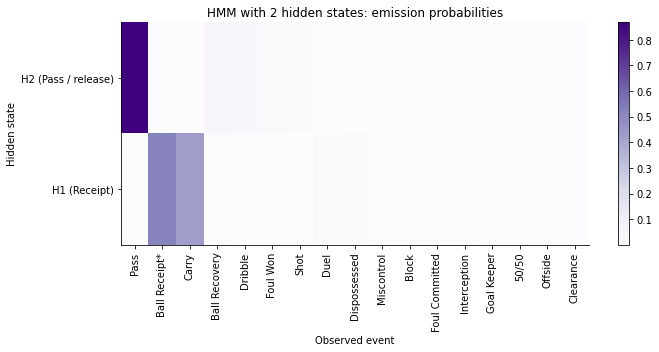

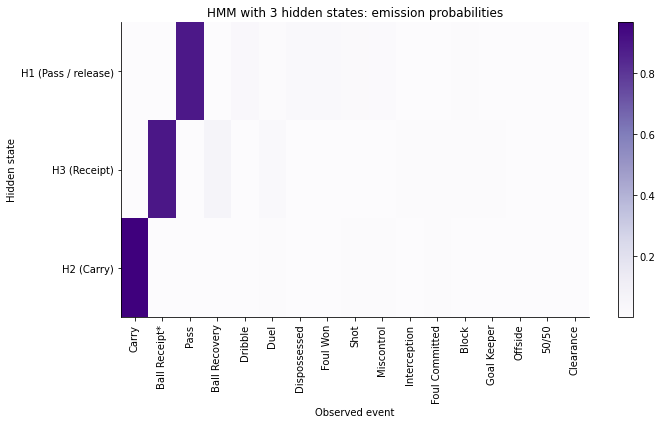

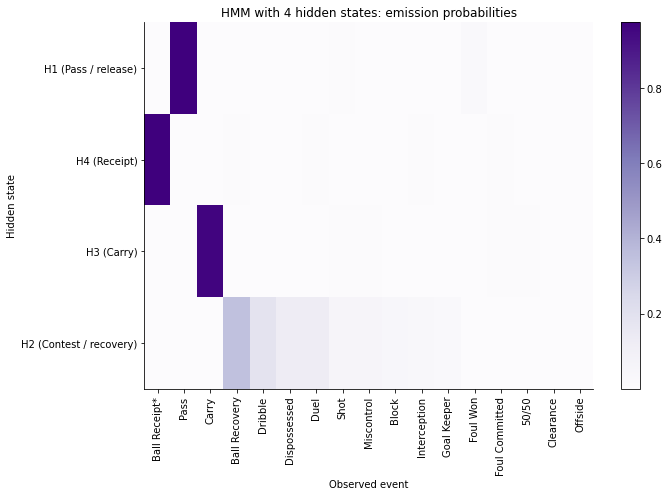

In [52]:
def emission_dataframe(model, observed_states):
    df = pd.DataFrame(
        model.emissionprob_,
        index=[f"H{i+1}" for i in range(model.n_hidden)],
        columns=observed_states,
    )
    reordered_df, order = reorder_hidden_states(df)
    labels = [hidden_state_label(reordered_df.loc[row].idxmax()) for row in reordered_df.index]
    reordered_df.index = [f"{row} ({label})" for row, label in zip(reordered_df.index, labels)]
    return reordered_df, order

def transition_dataframe(model, order):
    trans_df = pd.DataFrame(
        model.transmat_,
        index=[f"H{i+1}" for i in range(model.n_hidden)],
        columns=[f"H{i+1}" for i in range(model.n_hidden)],
    )
    reordered = trans_df.iloc[order, order]
    return reordered

for n_hidden in [2, 3, 4]:
    emit_df, order = emission_dataframe(hmm_models[n_hidden], states)
    top_cols = emit_df.max(axis=0).sort_values(ascending=False).index.tolist()
    plot_heatmap(
        emit_df.loc[:, top_cols],
        title=f"HMM with {n_hidden} hidden states: emission probabilities",
        xlabel="Observed event",
        ylabel="Hidden state",
        cmap="Purples",
        annotate=False,
        figsize=(10, 3 + n_hidden),
    )


In [53]:
for n_hidden in [2, 3, 4]:
    emit_df, order = emission_dataframe(hmm_models[n_hidden], states)
    summary_rows = []
    for hidden_state in emit_df.index:
        top5 = emit_df.loc[hidden_state].sort_values(ascending=False).head(5)
        summary_rows.append(
            {
                "hidden_state": hidden_state,
                "top emissions": ", ".join([f"{state} ({prob:.3f})" for state, prob in top5.items()]),
            }
        )
    display(pd.DataFrame(summary_rows))


,hidden_state,top emissions
0,H2 (Pass / release),"Pass (0.868), Ball Recovery (0.041), Dribble (..."
1,H1 (Receipt),"Ball Receipt* (0.516), Carry (0.421), Duel (0...."


,hidden_state,top emissions
0,H1 (Pass / release),"Pass (0.889), Dribble (0.029), Dispossessed (0..."
1,H3 (Receipt),"Ball Receipt* (0.892), Ball Recovery (0.060), ..."
2,H2 (Carry),"Carry (0.965), Duel (0.007), Shot (0.006), Mis..."


,hidden_state,top emissions
0,H1 (Pass / release),"Pass (0.970), Foul Won (0.022), Shot (0.008), ..."
1,H4 (Receipt),"Ball Receipt* (0.974), Duel (0.008), Foul Comm..."
2,H3 (Carry),"Carry (0.957), Miscontrol (0.011), Foul Commit..."
3,H2 (Contest / recovery),"Ball Recovery (0.348), Dribble (0.184), Dispos..."


The 4-state model is especially interpretable.

It typically discovers hidden states that look roughly like:

- a **pass / release** state,
- a **receipt** state,
- a **carry** state,
- and a **contest / recovery** state.

That is nice. It means the model is not inventing nonsense hidden states. It is discovering a compressed possession grammar that a soccer analyst can actually name.


,50/50,Ball Receipt*,Ball Recovery,Block,Carry,Clearance,Dispossessed,Dribble,Duel,Foul Committed,Foul Won,Goal Keeper,Interception,Miscontrol,Offside,Pass,Shot
H1 (Pass / release),0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0216,0.0000,0.0000,0.0000,0.0000,0.9701,0.0082
H4 (Receipt),0.0021,0.9738,0.0039,0.0018,0.0000,0.0000,0.0000,0.0000,0.0081,0.0064,0.0000,0.0000,0.0040,0.0000,0.0000,0.0000,0.0000
H3 (Carry),0.0051,0.0000,0.0000,0.0033,0.9571,0.0026,0.0000,0.0000,0.0036,0.0077,0.0000,0.0000,0.0025,0.0106,0.0026,0.0000,0.0049
H2 (Contest / recovery),0.0000,0.0000,0.3477,0.0445,0.0000,0.0000,0.1267,0.1843,0.1245,0.0001,0.0000,0.0231,0.0365,0.0562,0.0000,0.0000,0.0563


,H1,H4,H3,H2
H1,0.0064,0.9838,0.0000,0.0098
H4,0.2003,0.0000,0.7815,0.0182
H3,0.8941,0.0000,0.0000,0.1059
H2,0.0879,0.0000,0.6218,0.2903


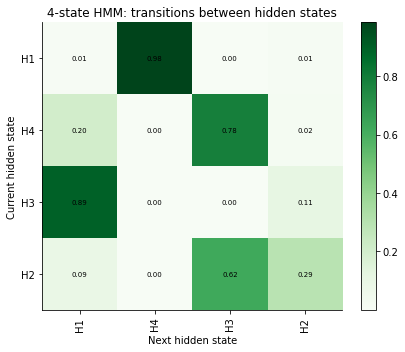

In [54]:
emit4_df, order4 = emission_dataframe(hmm_models[4], states)
trans4_df = transition_dataframe(hmm_models[4], order4)

display(emit4_df.round(4))
display(trans4_df.round(4))
plot_heatmap(
    trans4_df,
    title="4-state HMM: transitions between hidden states",
    xlabel="Next hidden state",
    ylabel="Current hidden state",
    cmap="Greens",
    annotate=True,
    figsize=(6, 5),
)


A few transitions are the key ones to notice.

- The pass-like state usually moves to the receipt-like state.
- The receipt-like state often moves to the carry-like state.
- The carry-like state often moves to the pass-like state.
- The contest/recovery state is where the possession can branch, recover, duel, or finish.

That is almost a textbook `Pass -> Receipt -> Carry -> Pass` loop, with a separate state for messy moments.


## 25. Decoding a real possession with Viterbi

Let's go back to possession 228 and ask a different question.

Not "what happens next?" but "what hidden state sequence best explains the observed events we saw?"


In [55]:
model4 = hmm_models[4]
target_encoded = np.array([state_to_idx[state] for state in target_sequence], dtype=int)
viterbi_path, _ = model4.decode_viterbi(target_encoded)

emit4_original = pd.DataFrame(
    model4.emissionprob_,
    index=[f"H{i+1}" for i in range(model4.n_hidden)],
    columns=states,
)

hidden_name_map = {}
for hidden_state in emit4_original.index:
    hidden_name_map[hidden_state] = hidden_state_label(emit4_original.loc[hidden_state].idxmax())

decoded_df = pd.DataFrame(
    {
        "step": np.arange(1, len(target_sequence) + 1),
        "observed_event": target_sequence,
        "decoded_hidden_state": [f"H{i+1}" for i in viterbi_path],
    }
)
decoded_df["decoded_hidden_label"] = decoded_df["decoded_hidden_state"].map(hidden_name_map)
display(decoded_df)


,step,observed_event,decoded_hidden_state,decoded_hidden_label
0,1,Ball Recovery,H2,Contest / recovery
1,2,Carry,H3,Carry
2,3,Pass,H1,Pass / release
3,4,Ball Receipt*,H4,Receipt
4,5,Carry,H3,Carry
5,6,Pass,H1,Pass / release
6,7,Ball Receipt*,H4,Receipt
7,8,Pass,H1,Pass / release
8,9,Ball Receipt*,H4,Receipt
9,10,Carry,H3,Carry


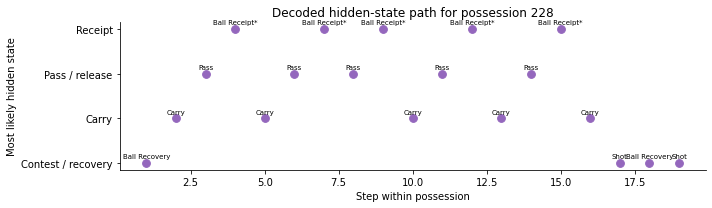

In [56]:
hidden_labels_in_order = decoded_df["decoded_hidden_label"].tolist()
unique_hidden_labels = list(dict.fromkeys(hidden_labels_in_order))
hidden_to_y = {label: i for i, label in enumerate(unique_hidden_labels)}

fig, ax = plt.subplots(figsize=(10, 3))
ax.scatter(
    decoded_df["step"],
    [hidden_to_y[label] for label in hidden_labels_in_order],
    s=60,
    color=COLOR_LATENT,
)
for _, row in decoded_df.iterrows():
    ax.text(
        row["step"],
        hidden_to_y[row["decoded_hidden_label"]] + 0.08,
        row["observed_event"],
        ha="center",
        va="bottom",
        fontsize=7,
    )
ax.set_yticks(list(hidden_to_y.values()))
ax.set_yticklabels(list(hidden_to_y.keys()))
ax.set_title("Decoded hidden-state path for possession 228")
ax.set_xlabel("Step within possession")
ax.set_ylabel("Most likely hidden state")
fig.tight_layout()
plt.show()


That decoded path is the HMM payoff in its clearest form.

The observed sequence looks like a string of surface events. The hidden-state path shows a more stable tactical rhythm underneath it:

- contest/recovery,
- carry,
- pass/release,
- receipt,
- carry again,
- and then eventually a finish.

This is why the HMM can predict better. It is not trying to memorize every visible pair. It is carrying a compact, persistent summary of where the possession seems to be.


## 26. Limits of the HMM story

We should be excited, but not sloppy.

An HMM is still making strong assumptions:

- the hidden state is **discrete**,
- hidden-state dynamics are **first-order**,
- emissions depend only on the current hidden state,
- there is no explicit player identity, location, pressure field, or clock effect unless we build those into the observed state.

Real soccer is richer than that. Possessions unfold in space, players matter, and timing matters.

So the HMM is not "the answer." It is a bridge idea. It teaches us how latent structure can matter before we move to richer sequence models.


## 26A. Truly new games: does the model transfer?

One harder prediction question is still missing.

Up to now, even our holdout data mostly lived inside one match. That is useful, but it is not the same as transfer to a genuinely new game. A new possession from the same match still shares the same teams, the same referee, the same tournament context, and a lot of the same tactical grammar.

So now we will freeze the state design at the same coarse event labels and move to a whole-match split.

- **Training matches:** Argentina's first five matches of the 2022 World Cup, from group stage through quarter-final
- **Validation/checkpoint match:** Argentina vs. France, 2022 final
- **Test match A:** Argentina vs. Croatia, 2022 semifinal
- **Test match B:** an older European knockout match

There is one small calendar correction to make. There was no men's UEFA Euro in 2018. So for the "older European game" comparator we will use **France vs. Belgium in the 2018 World Cup semifinal**, and we will score **France possessions** from that match. That gives us an unseen European knockout game from a different era.

We are not tuning any hyperparameters here, so the validation/checkpoint label is just that: a checkpoint. The real leakage rule is simpler. **Nothing from the validation or test matches is used when fitting the model.**


In [57]:
import urllib.request

OPEN_DATA_BASE_URL = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"

def ensure_open_data_json(relative_path):
    relative_path = Path(relative_path)
    local_path = DATA_ROOT / relative_path
    local_path.parent.mkdir(parents=True, exist_ok=True)

    if not local_path.exists():
        url = f"{OPEN_DATA_BASE_URL}/{relative_path.as_posix()}"
        print(f"Downloading {relative_path} from StatsBomb open data ...")
        urllib.request.urlretrieve(url, local_path)

    return local_path

def load_statsbomb_events_df(match_id):
    event_path = ensure_open_data_json(Path("events") / f"{match_id}.json")
    with open(event_path) as f:
        match_events = json.load(f)

    df = pd.json_normalize(match_events, sep=".")
    df = df.rename(columns=RENAME_MAP).copy()

    if "under_pressure" in df.columns:
        df["under_pressure"] = (
            df["under_pressure"]
            .where(df["under_pressure"].notna(), False)
            .astype(bool)
        )
    else:
        df["under_pressure"] = False

    df["is_gameplay"] = ~df["event_type"].isin(STRUCTURAL_EVENTS)
    df[["x", "y"]] = df["location"].apply(lambda loc: pd.Series(extract_xy(loc)))
    return df

def load_statsbomb_matches(competition_id, season_id):
    matches_path = ensure_open_data_json(Path("matches") / str(competition_id) / f"{season_id}.json")
    with open(matches_path) as f:
        return json.load(f)

matches_2022 = load_statsbomb_matches(43, 106)
matches_2018 = load_statsbomb_matches(43, 3)
match_lookup_transfer = {match["match_id"]: match for match in matches_2022 + matches_2018}

def match_label_transfer(match_id):
    match = match_lookup_transfer[match_id]
    return (
        f"{match['home_team']['home_team_name']} vs "
        f"{match['away_team']['away_team_name']} "
        f"({match['match_date']})"
    )

def team_sequences_for_match(match_id, team_name, state_func=state_coarse):
    match_df = load_statsbomb_events_df(match_id)
    team_df = build_team_possession_slice(match_df, team_name, periods=(1, 2, 3, 4), state_func=state_func)
    sequences_match, meta_match = extract_sequences_from_df(team_df)
    return sequences_match, meta_match, team_df

train_match_ids_transfer = [3857300, 3857289, 3857264, 3869151, 3869321]
validation_spec_transfer = {
    "match_id": 3869685,
    "team_name": "Argentina",
    "label": "Validation/checkpoint: 2022 final",
}
test_specs_transfer = [
    {
        "match_id": 3869519,
        "team_name": "Argentina",
        "label": "Test: 2022 semifinal vs Croatia",
    },
    {
        "match_id": 8655,
        "team_name": "France",
        "label": "Test: 2018 European comparator (France vs Belgium semifinal)",
    },
]

transfer_train_sequences = []
transfer_split_rows = []

for match_id in train_match_ids_transfer:
    seqs_match, meta_match, _ = team_sequences_for_match(match_id, "Argentina")
    transfer_train_sequences.extend(seqs_match)
    transfer_split_rows.append(
        {
            "role": "train",
            "match": match_label_transfer(match_id),
            "team_slice": "Argentina",
            "stage": match_lookup_transfer[match_id]["competition_stage"]["name"],
            "possessions": len(seqs_match),
            "transitions": int(sum(len(seq) - 1 for seq in seqs_match)),
        }
    )

for spec in [validation_spec_transfer] + test_specs_transfer:
    seqs_match, meta_match, _ = team_sequences_for_match(spec["match_id"], spec["team_name"])
    spec["sequences"] = seqs_match
    transfer_split_rows.append(
        {
            "role": "validation/checkpoint" if "Validation" in spec["label"] else "test",
            "match": match_label_transfer(spec["match_id"]),
            "team_slice": spec["team_name"],
            "stage": match_lookup_transfer[spec["match_id"]]["competition_stage"]["name"],
            "possessions": len(seqs_match),
            "transitions": int(sum(len(seq) - 1 for seq in seqs_match)),
        }
    )

transfer_split_summary = pd.DataFrame(transfer_split_rows)
display(transfer_split_summary)


,role,match,team_slice,stage,possessions,transitions
0,train,Argentina vs Saudi Arabia (2022-11-22),Argentina,Group Stage,88,1774
1,train,Argentina vs Mexico (2022-11-26),Argentina,Group Stage,79,1555
2,train,Poland vs Argentina (2022-11-30),Argentina,Group Stage,62,2574
3,train,Argentina vs Australia (2022-12-03),Argentina,Round of 16,81,2105
4,train,Netherlands vs Argentina (2022-12-09),Argentina,Quarter-finals,105,1755
5,validation/checkpoint,Argentina vs France (2022-12-18),Argentina,Final,109,1821
6,test,Argentina vs Croatia (2022-12-13),Argentina,Semi-finals,87,1159
7,test,France vs Belgium (2018-07-10),France,Semi-finals,74,941


### Pause and guess

Which held-out **test** game do you think the trained model will predict better?

1. `Argentina vs Croatia`, 2022 semifinal — score **Argentina** possessions
2. `France vs Belgium`, 2018 World Cup semifinal — score **France** possessions

Write down a guess before running the next cell. Then write one sentence explaining why. Same team? Same tournament? Same era? Similar tactical style? Different competitive pressure?


In [58]:
states_transfer = sorted(TEAM_ACTION_TYPES)
state_to_idx_transfer = {state: i for i, state in enumerate(states_transfer)}

transfer_counts = transition_counts(transfer_train_sequences, states_transfer)
transfer_P = row_normalize(transfer_counts)
transfer_marginal = marginal_distribution(transfer_train_sequences, states_transfer)

def predict_transfer_first_order(context):
    return transfer_P[state_to_idx_transfer[context[-1]]]

def predict_transfer_marginal(context):
    return transfer_marginal

transfer_score_rows = []

for spec in [validation_spec_transfer] + test_specs_transfer:
    first_order_transfer_score = score_next_event_model(
        spec["sequences"],
        predict_transfer_first_order,
        states=states_transfer,
        state_to_idx=state_to_idx_transfer,
        min_context_len=1,
    )
    marginal_transfer_score = score_next_event_model(
        spec["sequences"],
        predict_transfer_marginal,
        states=states_transfer,
        state_to_idx=state_to_idx_transfer,
        min_context_len=1,
    )

    for model_name, score_obj in [
        ("Marginal baseline", marginal_transfer_score),
        ("First-order Markov", first_order_transfer_score),
    ]:
        transfer_score_rows.append(
            {
                "evaluation_set": spec["label"],
                "model": model_name,
                "transitions_scored": score_obj["n_transitions"],
                "log_loss_nats": score_obj["mean_log_loss_nats"],
                "perplexity": score_obj["perplexity"],
                "zero_prob_hits": int((score_obj["details"]["prob_true_raw"] == 0).sum()),
            }
        )

transfer_score_df = pd.DataFrame(transfer_score_rows)
display(transfer_score_df.round(4))


,evaluation_set,model,transitions_scored,log_loss_nats,perplexity,zero_prob_hits
0,Validation/checkpoint: 2022 final,Marginal baseline,1821,1.5232,4.5870,1
1,Validation/checkpoint: 2022 final,First-order Markov,1821,0.7527,2.1227,9
2,Test: 2022 semifinal vs Croatia,Marginal baseline,1159,1.4524,4.2733,0
3,Test: 2022 semifinal vs Croatia,First-order Markov,1159,0.5224,1.6861,0
4,Test: 2018 European comparator (France vs Belg...,Marginal baseline,941,1.4745,4.3688,0
5,Test: 2018 European comparator (France vs Belg...,First-order Markov,941,0.6493,1.9142,1


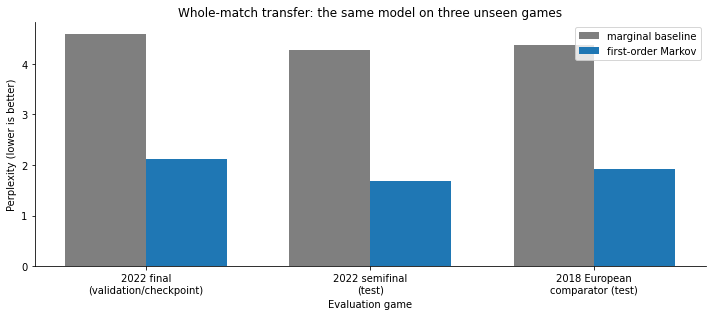

In [59]:
transfer_plot_df = (
    transfer_score_df.pivot(index="evaluation_set", columns="model", values="perplexity")
    .loc[
        [
            "Validation/checkpoint: 2022 final",
            "Test: 2022 semifinal vs Croatia",
            "Test: 2018 European comparator (France vs Belgium semifinal)",
        ]
    ]
)

x = np.arange(len(transfer_plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(
    x - width / 2,
    transfer_plot_df["Marginal baseline"],
    width=width,
    color=COLOR_REFERENCE,
    label="marginal baseline",
)
ax.bar(
    x + width / 2,
    transfer_plot_df["First-order Markov"],
    width=width,
    color=COLOR_MAIN,
    label="first-order Markov",
)

ax.set_xticks(x)
ax.set_xticklabels(
    [
        "2022 final\n(validation/checkpoint)",
        "2022 semifinal\n(test)",
        "2018 European\ncomparator (test)",
    ]
)
ax.set_title("Whole-match transfer: the same model on three unseen games")
ax.set_xlabel("Evaluation game")
ax.set_ylabel("Perplexity (lower is better)")
ax.legend()
fig.tight_layout()
plt.show()


On the two **test** games, the model does better on the unseen Argentina semifinal than on the older European comparator. That is exactly the direction many students guess, and it makes soccer sense: same team, same coach, same tournament, same roster core, same era, and a nearby knockout context.

The older France-vs-Belgium semifinal is still far better than the marginal baseline, so the learned event grammar is not useless out of domain. But it is a harder transfer setting. Team identity, competition context, era, and tactical style all shift.

There is also a fun wrinkle here: the 2022 final checkpoint is actually harder than the 2018 European comparator under this training corpus. Finals can do that. Fatigue, score effects, extra time, and the weirdness of a final can bend the event grammar in ways that a pooled earlier-tournament model does not fully absorb.

That is the big generalization lesson. **A new possession from the same match and a whole new match are not the same prediction problem.** Whole-match transfer is not just a stricter split. It is a domain-shift question.


# Part V — Synthesis

## 27. What each model assumes, and what it gains

Let's line up the models conceptually as well as numerically.


In [60]:
assumption_table = pd.DataFrame(
    [
        {
            "model": "Uniform",
            "what_it_conditions_on": "Nothing",
            "main_assumption": "All next states are equally likely",
            "strength": "Pure know-nothing baseline",
            "main_failure_mode": "Ignores both base rates and context",
        },
        {
            "model": "Marginal",
            "what_it_conditions_on": "Global next-state frequencies",
            "main_assumption": "Only base rates matter",
            "strength": "Learns common events",
            "main_failure_mode": "Ignores current state",
        },
        {
            "model": "First-order Markov",
            "what_it_conditions_on": "Current state only",
            "main_assumption": "The present state summarizes all useful history",
            "strength": "Simple, interpretable, useful",
            "main_failure_mode": "Misses context effects and rare branches",
        },
        {
            "model": "Second-order Markov",
            "what_it_conditions_on": "Previous two states",
            "main_assumption": "Two-step memory is enough",
            "strength": "Captures local path dependence",
            "main_failure_mode": "Sparsity and overfitting",
        },
        {
            "model": "HMM",
            "what_it_conditions_on": "Filtered hidden state distribution",
            "main_assumption": "A small latent tactical phase drives visible events",
            "strength": "Compact memory with interpretable hidden roles",
            "main_failure_mode": "Latent state may still be too coarse",
        },
    ]
)

display(assumption_table)


,model,what_it_conditions_on,main_assumption,strength,main_failure_mode
0,Uniform,Nothing,All next states are equally likely,Pure know-nothing baseline,Ignores both base rates and context
1,Marginal,Global next-state frequencies,Only base rates matter,Learns common events,Ignores current state
2,First-order Markov,Current state only,The present state summarizes all useful history,"Simple, interpretable, useful",Misses context effects and rare branches
3,Second-order Markov,Previous two states,Two-step memory is enough,Captures local path dependence,Sparsity and overfitting
4,HMM,Filtered hidden state distribution,A small latent tactical phase drives visible e...,Compact memory with interpretable hidden roles,Latent state may still be too coarse


The most important conceptual difference is this:

- the Markov models condition on **observed history directly**,
- the HMM conditions on a **compressed latent summary of history**.

That is why the HMM can win even when the raw second-order model struggles.


## 28. Where this goes next

Today's notebook should make several later ideas feel less mysterious.

- **VAEP** and related action-value models also ask predictive questions about what happens next, just with richer targets than a single next event.
- **Expected possession value** models push from event labels toward richer spatial and temporal state descriptions.
- **RNNs** and **transformers** can be seen as more flexible ways to summarize history.
- **Continuous-time** models matter once timing itself becomes part of the state.

So this notebook is not a side road. It is a bridge from simple networks to modern sequence models.


## Summary

The central idea of class 17 is short and worth remembering:

An event-transition network is not just a picture. Once we row-normalize it, it becomes a predictive model.

From there, everything else follows naturally.

- We scored predictions with log-loss because probabilities matter, not just top-1 guesses.
- We used baselines so that the first-order model's score meant something.
- We saw a genuine second-order effect, but also saw why raw higher-order tables overfit.
- We stress-tested the learned transition network with controlled rewiring and saw that small perturbations do not destroy the score, but large randomization does.
- We tried richer observed labels — pressure-aware and location-aware states — and saw the sparsity tradeoff directly.
- We named the underlying object properly: a Markov chain.
- We used `START` and `END` to talk about stationary behavior, absorption, expected possession length, and simulation.
- We tested transfer to whole unseen matches and saw that similarity of team, era, and competition context matters.
- We introduced HMMs as models with hidden tactical phases and saw that a small categorical HMM can predict much better on this strict holdout split.

So the lesson is not "just add more complexity." The lesson is sharper than that.

**Use the simplest model that captures the dependence structure you actually need.**


# Appendices

## Appendix A — Why the restart-chain stationary distribution is useful

For the one-possession chain with absorbing `END`, the stationary distribution collapses onto `END`. That is mathematically correct but analytically boring.

The restart chain fixes that by making `END -> START` with probability $1$. Then the chain keeps moving across possessions, and the stationary distribution becomes a meaningful long-run occupancy summary.

In practice, that restart-chain stationary distribution is closely connected to the empirical share of time spent in each state across many possessions. That is why it gives an intuitive comparison target.


## Appendix B — Why scaling matters in the forward-backward algorithm

Forward probabilities for HMMs multiply a lot of small numbers. Without care, they underflow numerically.

The fix is to normalize at each time step. That is what the scaling factors are doing in our implementation. They keep the filtered probabilities well-behaved while still letting us reconstruct the overall sequence log-likelihood from the accumulated scale terms.

So the scaling trick is not a mathematical change to the model. It is a numerical-stability trick.


## Exercises and project starters

### Prediction and evaluation

1. Redo the notebook with France instead of Argentina. Which parts of the model ladder change the most?
2. Keep the same team but switch from the coarse state space to one of the richer state spaces from class 16. Does the first-order model improve? Does sparsity wipe out the gain?
3. Add Laplace smoothing directly to the first-order transition matrix and compare its held-out score with the unsmoothed version.

### Higher-order structure

4. Find a current state besides `Carry` where the second-order effect is large. Write down the tactical interpretation in plain soccer language.
5. Extend the backoff model so that $\alpha$ depends on the current state. Which states need the strongest skepticism?

### HMM extensions

6. Fit 5 or 6 hidden states. Do you get genuinely new tactical roles, or just state splitting?
7. Replace the coarse observed state with a state that includes `under_pressure`. Does one hidden state become more clearly associated with pressure?
8. Instead of using only event labels, include a coarse pitch-zone label from class 15 and fit an HMM on that richer observation alphabet.

### Open-ended project ideas

9. Build a possession-value target and ask whether hidden states improve *value prediction* rather than just next-event prediction.
10. Compare a first-order Markov model, a 4-state HMM, and a small recurrent neural model on the same train/test split.
11. Use multiple matches and ask whether hidden states are team-specific, match-specific, or stable across contexts.


## References

### Data, event semantics, and football network context

- **StatsBomb.** *StatsBomb Open Data repository.* GitHub. The core public event-data source used throughout classes 13–17. Repository: `statsbomb/open-data`.
- **StatsBomb.** *StatsBomb Open Data Specification v1.1.* 2019. The schema reference that clarifies event fields, nested attributes, and details such as missing `pass.outcome` for completed passes.
- **Buldú, J. M., Busquets, J., Martínez, J. H., Herrera-Diestra, J. L., Echegoyen, I., Galeano, J., & Luque, J.** (2018). *Using Network Science to Analyse Football Passing Networks.* *Frontiers in Psychology*, 9, 1900. A broad review of football passing networks and why network structure can reveal team organization.
- **Cintia, P., Pappalardo, L., & Rinzivillo, S.** (2015). *A network-based approach to evaluate the performance of football teams.* In *Machine Learning and Data Mining for Sports Analytics* (ECML/PKDD workshop, CEUR-WS, pp. 46–54). A compact example of football-team evaluation through network summaries.
- **Hughes, M., & Franks, I.** (2005). *Analysis of passing sequences, shots and goals in soccer.* *Journal of Sports Sciences*, 23(5), 509–514. A useful correction to over-simple readings of short passing sequences.
- **Reep, C., & Benjamin, B.** (1968). *Skill and Chance in Association Football.* *Journal of the Royal Statistical Society. Series A (General)*, 131(4), 581–585. A foundational early paper in football sequence analysis, historically important even where later analysts disagree with its conclusions.
- **Tenga, A., Holme, I., Ronglan, L. T., & Bahr, R.** (2010). *Effect of playing tactics on achieving score-box possessions in a random series of team possessions from Norwegian professional soccer matches.* *Journal of Sports Sciences*, 28(3), 245–255. A classic possession-analysis paper that treats sequences as meaningful tactical units.


### Markov chains, action value, and sequence models in football

- **Rudd, S.** (2011). *A Framework for Tactical Analysis and Individual Offensive Production Assessment in Soccer Using Markov Chains.* New England Symposium on Statistics in Sports. One of the early landmark football analytics papers to use Markov chains for possession value.
- **López Peña, J.** (2014). *A Markovian model for association football possession and its outcomes.* arXiv:1403.7993. A clear football possession model that stays very close to the Markov-chain viewpoint.
- **Decroos, T., Bransen, L., Van Haaren, J., & Davis, J.** (2019). *Actions Speak Louder than Goals: Valuing Player Actions in Soccer.* In *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining* (pp. 1851–1861). The VAEP paper. A major step from raw events toward contextual action valuation.
- **Fernández, J., Bornn, L., & Cervone, D.** (2021). *A framework for the fine-grained evaluation of the instantaneous expected value of soccer possessions.* *Machine Learning*, 110, 1389–1427. A rich EPV-style framework for soccer that uses much more state detail than our notebook does.
- **Van Roy, M., Robberechts, P., Decroos, T., & Davis, J.** (2020). *A Critical Comparison of xT and VAEP.* In *Proceedings of the AAAI Workshop on Artificial Intelligence in Team Sports.* A very useful conceptual comparison of two canonical action-value approaches.
- **Robberechts, P., Van Haaren, J., & Davis, J.** (2019). *Valuing the Art of Pressing.* In *Proceedings of the 13th MIT Sloan Sports Analytics Conference.* Introduces VPEP, extending event-value ideas toward defensive pressure.
- **Merckx, S., Robberechts, P., Wyseur, M., Van Haaren, J., & Davis, J.** (2021). *Measuring the Effectiveness of Pressing in Soccer.* In *Proceedings of the Machine Learning and Data Mining for Sports Analytics Workshop.* Another strong example of extending sequence-value thinking to defensive actions.
- **Robberechts, P., Van Roy, M., & Davis, J.** (2023). *un-xPass: Measuring Soccer Player's Creativity.* In *Proceedings of the 29th ACM SIGKDD Conference on Knowledge Discovery and Data Mining.* Shows how predictive and value-based ideas can be pushed into pass originality and creativity.
- **Cervone, D., D’Amour, A., Bornn, L., & Goldsberry, K.** (2016). *A Multiresolution Stochastic Process Model for Predicting Basketball Possession Outcomes.* *Journal of the American Statistical Association*, 111(514), 585–599. Not soccer, but one of the clearest possession-value bridges from sequence modeling to richer spatiotemporal state models.


### Scoring rules, information theory, and probabilistic prediction

- **Shannon, C. E.** (1948). *A Mathematical Theory of Communication.* *Bell System Technical Journal*, 27(3), 379–423; 27(4), 623–656. The foundational entropy paper behind cross-entropy and perplexity.
- **Good, I. J.** (1952). *Rational Decisions.* *Journal of the Royal Statistical Society: Series B (Methodological)*, 14(1), 107–114. A classical source for the log score and probabilistic decision-making.
- **Gneiting, T., & Raftery, A. E.** (2007). *Strictly Proper Scoring Rules, Prediction, and Estimation.* *Journal of the American Statistical Association*, 102(477), 359–378. The clean modern reference on why proper scoring rules matter.
- **Bishop, C. M.** (2006). *Pattern Recognition and Machine Learning.* Springer. A standard machine-learning text with clear discussion of probabilistic modeling and cross-entropy.
- **Murphy, K. P.** (2012). *Machine Learning: A Probabilistic Perspective.* MIT Press. Especially useful for seeing cross-entropy, sequence models, and HMMs in one place.
- **scikit-learn developers.** *`log_loss` documentation.* A practical API-level reference for the standard machine-learning interpretation of log-loss as cross-entropy / negative log-likelihood.


### Markov chain theory and higher-order network models

- **Kemeny, J. G., & Snell, J. L.** (1976). *Finite Markov Chains.* Springer. A classic text, especially strong on absorbing chains and the fundamental matrix.
- **Norris, J. R.** (1997). *Markov Chains.* Cambridge University Press. A concise mathematically careful treatment of finite and countable-state chains.
- **Levin, D. A., Peres, Y., & Wilmer, E. L.** (2017). *Markov Chains and Mixing Times* (2nd ed.). American Mathematical Society. The best modern textbook for long-run behavior and convergence.
- **Grinstead, C. M., & Snell, J. L.** (1997/2024 online edition). *Introduction to Probability.* A student-friendly open text with strong chapters on Markov chains and absorbing states.
- **Newman, M.** (2018). *Networks* (2nd ed.). Oxford University Press. A modern network-science textbook that puts Markov processes and random walks in the broader language of networks.
- **Barabási, A.-L.** (2016). *Network Science.* Cambridge University Press. Helpful for the random-walk and network-process background around today's transition models.
- **Easley, D., & Kleinberg, J.** (2010). *Networks, Crowds, and Markets.* Cambridge University Press. A broad text with many examples of stochastic processes on networks.
- **Rosvall, M., Esquivel, A. V., Lancichinetti, A., West, J. D., & Lambiotte, R.** (2014). *Memory in network flows and its effects on spreading dynamics and community detection.* *Nature Communications*, 5, 4630. A central warning that first-order network representations can hide real memory.
- **Scholtes, I.** (2017). *When is a Network a Network? Multi-Order Graphical Model Selection in Pathways and Temporal Networks.* In *Proceedings of the 23rd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining* (pp. 1037–1046). A strong formal treatment of why network abstractions can fail for sequential data.
- **Lambiotte, R., Rosvall, M., & Scholtes, I.** (2019). *From networks to optimal higher-order models of complex systems.* *Nature Physics*, 15(4), 313–320. A broad review of higher-order models and why they matter.
- **Xu, J., Wickramarathne, T. L., & Chawla, N. V.** (2016). *Representing higher-order dependencies in networks.* *Science Advances*, 2(5), e1600028. A useful reference on variable-order dependencies embedded in network representations.


### Hidden Markov Models: foundations, algorithms, and software

- **Baum, L. E., & Petrie, T.** (1966). *Statistical Inference for Probabilistic Functions of Finite State Markov Chains.* *The Annals of Mathematical Statistics*, 37(6), 1554–1563. One of the foundational HMM papers.
- **Baum, L. E., Petrie, T., Soules, G., & Weiss, N.** (1970). *A Maximization Technique Occurring in the Statistical Analysis of Probabilistic Functions of Markov Chains.* *The Annals of Mathematical Statistics*, 41(1), 164–171. The core Baum-Welch / EM paper for HMM parameter estimation.
- **Viterbi, A. J.** (1967). *Error Bounds for Convolutional Codes and an Asymptotically Optimum Decoding Algorithm.* *IEEE Transactions on Information Theory*, 13(2), 260–269. The original dynamic-programming decoding paper behind the Viterbi algorithm.
- **Rabiner, L. R.** (1989). *A Tutorial on Hidden Markov Models and Selected Applications in Speech Recognition.* *Proceedings of the IEEE*, 77(2), 257–286. Still the standard tutorial. If you read one HMM tutorial, read this one.
- **Bilmes, J. A.** (1998). *A Gentle Tutorial of the EM Algorithm and its Application to Parameter Estimation for Gaussian Mixture and Hidden Markov Models.* ICSI Technical Report TR-97-021. A very readable learning-oriented explanation of EM and Baum-Welch.
- **Stamp, M.** (2021). *A revealing introduction to hidden Markov models.* Department of Computer Science, San Jose State University. A compact pedagogical tutorial with clean examples.
- **hmmlearn developers.** (2025). *hmmlearn documentation.* Practical software documentation for Gaussian, multinomial, and categorical HMM variants in Python.


### Bridges to later sequence models

- **Hochreiter, S., & Schmidhuber, J.** (1997). *Long Short-Term Memory.* *Neural Computation*, 9(8), 1735–1780. The classic recurrent model that learns long-range sequence dependence.
- **Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I.** (2017). *Attention Is All You Need.* In *Advances in Neural Information Processing Systems* 30. The transformer paper. The modern baseline for many sequence tasks.
- **Singh, K.** (2019). *Introducing Expected Threat (xT).* StatsBomb / blog exposition. Not a journal paper, but a very influential practical bridge from event location to action value in football analytics.
